# AI Insight Sprint™
## Case Study #2 — Nigeria Tax Revenue & Compliance Intelligence

**Prepared by:** Joshua Odekina  
**Framework:** AI Insight Sprint™  
**Industry:** Tax Administration & Public Revenue  
**Geography:** Nigeria  
**Tools:** Python, Pandas, NumPy, Matplotlib & Power BI

# 01. Executive Overview

## Purpose

This case study examines Nigeria tax revenue and compliance data to identify patterns in taxpayer activity, assessments, payments, revenue performance, and compliance behavior.

The analysis is designed to answer a central business question:

> **How can tax administration data be transformed into actionable intelligence for improving revenue performance and taxpayer compliance?**

Using the AI Insight Sprint™ framework, the project evaluates the available data across five major intelligence areas:

- Revenue performance
- Compliance behavior
- Taxpayer characteristics
- Geographic patterns
- Executive decision opportunities

The final output is intended to move beyond descriptive reporting by translating observed data patterns into practical actions for revenue administration.

### Expected Business Value

The analysis seeks to help decision-makers:

- Understand revenue and payment performance
- Identify compliance gaps and risk patterns
- Segment taxpayers for targeted interventions
- Identify geographic areas requiring attention
- Prioritize revenue and compliance opportunities
- Support evidence-based administrative decisions

**Core principle:**  
*The goal is not simply to report what happened, but to understand what it means and what should happen next.*

# 02. Business Context & Problem Statement

## Business Context

Tax administration depends on the ability to accurately identify taxpayers, assess their liabilities, monitor payments, and understand compliance behavior.

As taxpayer populations and transaction volumes increase, relying solely on manual reporting can make it difficult to identify emerging revenue opportunities, compliance gaps, and areas requiring administrative attention.

Data provides an opportunity to move from reactive monitoring toward more structured and evidence-based revenue intelligence.

## Business Problem

The available taxpayer, assessment, and payment records contain valuable information about revenue generation and compliance behavior. However, raw transactional data does not automatically provide decision-ready intelligence.

The key challenge is to determine:

- Where revenue is being generated
- Where assessed liabilities are not translating into payments
- Which taxpayer groups require greater attention
- Which geographic areas show stronger or weaker performance
- Where potential compliance and revenue opportunities exist

This case study therefore applies a structured analytical approach to transform the available raw data into actionable tax revenue and compliance intelligence.

## Problem Statement

> **How can taxpayer, assessment, payment, and tax-calendar data be analyzed to identify revenue opportunities, compliance gaps, taxpayer patterns, and geographic priorities that can support better tax administration decisions in Nigeria?**

# 03. Project Objectives

The primary objective of this case study is to transform tax administration data into practical revenue and compliance intelligence.

### Specific Objectives

1. **Assess data quality**  
   Evaluate the completeness, consistency, uniqueness, and integrity of the available datasets.

2. **Measure revenue performance**  
   Analyze assessments, payments, collections, and related revenue indicators.

3. **Evaluate compliance behavior**  
   Identify patterns between taxpayer obligations and payment activity.

4. **Understand taxpayer segments**  
   Analyze taxpayer characteristics and identify meaningful behavioral patterns.

5. **Assess geographic performance**  
   Examine revenue and compliance patterns across available geographic dimensions.

6. **Generate AI-powered insights**  
   Translate analytical findings into concise business interpretations and potential opportunities.

7. **Support executive decision-making**  
   Convert findings into prioritized recommendations that can support revenue administration and compliance strategies.

# 04. Key Business Questions

The analysis is structured around the following business questions:

### Revenue Intelligence

1. How much revenue has been assessed and collected?
2. How does payment performance vary across tax types and other available dimensions?
3. Where are the strongest and weakest revenue performance areas?

### Compliance Intelligence

4. What proportion of assessed liabilities has been paid?
5. Where are the largest gaps between assessments and payments?
6. Which patterns may indicate potential compliance concerns?

### Taxpayer Intelligence

7. What taxpayer segments contribute the greatest revenue?
8. How does compliance behavior vary across taxpayer characteristics?
9. Which taxpayer groups may represent high-value opportunities for targeted engagement?

### Geographic Intelligence

10. Which locations demonstrate stronger revenue performance?
11. Which geographic areas show potential compliance or collection gaps?
12. Where should administrative attention potentially be prioritized?

### Executive Decision Intelligence

13. What are the most important insights emerging from the data?
14. Which findings have the greatest potential business impact?
15. What actions should decision-makers consider based on the evidence?

# 05. Data Sources & Dataset Architecture

## Data Sources

The analysis uses four raw datasets representing key components of the tax administration process:

| Dataset | Purpose | Analytical Role |
|---|---|---|
| Taxpayers | Taxpayer master information | Taxpayer profiling |
| Assessments | Tax liabilities assessed | Revenue obligation analysis |
| Payments | Recorded taxpayer payments | Collection & compliance analysis |
| Tax Calendar | Tax type and filing-calendar reference information | Tax-type validation and compliance context |

## Dataset Architecture

The datasets are connected through identifiable business relationships.

**Taxpayers**  
↓  
**Assessments**  
↓  
**Payments**

The **Tax Calendar** provides additional reference information that can be used to interpret tax types, periods, and compliance timing where applicable.

### Analytical Flow

**Taxpayer Profile**  
→ **Tax Assessment**  
→ **Payment Activity**  
→ **Compliance Position**  
→ **Revenue Intelligence**  
→ **Executive Decision**

The raw datasets will be preserved unchanged. Data cleaning, validation, and derived analytical tables will be handled separately so that the original source data remains available for auditability and reconciliation.

This case study uses four related datasets representing taxpayers, tax assessments, payments, and tax filing-calendar information.

**Data Note:** This case study uses a simulated tax administration dataset created for analytical demonstration and portfolio purposes. It does not represent official Nigerian government revenue records.

# 06. Data Dictionary

The data dictionary defines the fields available within each source dataset and establishes their intended analytical meaning.

The dictionary will be validated against the raw datasets before analysis begins.

This provides a common reference for:

- Field names
- Data types
- Business meaning
- Analytical usage
- Key identifiers
- Relationships between datasets

In [1]:
# ============================================================
# AI Insight Sprint™ — Case Study #2
# Section 06: Data Dictionary
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw datasets
taxpayers = pd.read_csv("taxpayers_raw.csv")
assessments = pd.read_csv("assessments_raw.csv")
payments = pd.read_csv("payments_raw.csv")
tax_calendar = pd.read_csv("tax_calendar.csv")

# Store datasets in a dictionary for easier inspection
datasets = {
    "Taxpayers": taxpayers,
    "Assessments": assessments,
    "Payments": payments,
    "Tax Calendar": tax_calendar
}

# Display dataset structures
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print("Fields:")
    print(list(df.columns))


Taxpayers
---------
Rows: 10,000
Columns: 6
Fields:
['taxpayer_id', 'state', 'lga', 'sector', 'business_size', 'registration_date']

Assessments
-----------
Rows: 25,000
Columns: 5
Fields:
['assessment_id', 'taxpayer_id', 'tax_type', 'assessment_date', 'assessed_amount']

Payments
--------
Rows: 20,010
Columns: 4
Fields:
['payment_id', 'assessment_id', 'payment_date', 'amount_paid']

Tax Calendar
------------
Rows: 4
Columns: 4
Fields:
['tax_type', 'tax_description', 'filing_frequency', 'typical_due_date']


In [2]:
# ============================================================
# Section 06 — Data Dictionary
# ============================================================

data_dictionary = {
    "Taxpayers": {
        "taxpayer_id": "Unique identifier assigned to each taxpayer",
        "state": "State where the taxpayer is registered",
        "lga": "Local Government Area of taxpayer registration",
        "sector": "Business or economic sector of the taxpayer",
        "business_size": "Classification of taxpayer business size",
        "registration_date": "Date the taxpayer was registered"
    },

    "Assessments": {
        "assessment_id": "Unique identifier assigned to each assessment",
        "taxpayer_id": "Identifier linking the assessment to a taxpayer",
        "tax_type": "Type of tax associated with the assessment",
        "assessment_date": "Date the tax assessment was issued or recorded",
        "assessed_amount": "Amount of tax liability assessed"
    },

    "Payments": {
        "payment_id": "Unique identifier assigned to each payment",
        "assessment_id": "Identifier linking the payment to an assessment",
        "payment_date": "Date the payment was recorded",
        "amount_paid": "Amount paid against the assessment"
    },

    "Tax Calendar": {
        "tax_type": "Tax type used to classify tax obligations",
        "tax_description": "Description of the corresponding tax type",
        "filing_frequency": "Expected frequency of tax filing",
        "typical_due_date": "Typical deadline associated with the tax type"
    }
}

# Convert dictionary to a structured table
dictionary_rows = []

for dataset, fields in data_dictionary.items():
    for field, description in fields.items():
        dictionary_rows.append({
            "Dataset": dataset,
            "Field": field,
            "Business Definition": description
        })

data_dictionary_df = pd.DataFrame(dictionary_rows)

# Display the complete data dictionary
display(data_dictionary_df)

,Dataset,Field,Business Definition
0,Taxpayers,taxpayer_id,Unique identifier assigned to each taxpayer
1,Taxpayers,state,State where the taxpayer is registered
2,Taxpayers,lga,Local Government Area of taxpayer registration
3,Taxpayers,sector,Business or economic sector of the taxpayer
4,Taxpayers,business_size,Classification of taxpayer business size
5,Taxpayers,registration_date,Date the taxpayer was registered
6,Assessments,assessment_id,Unique identifier assigned to each assessment
7,Assessments,taxpayer_id,Identifier linking the assessment to a taxpayer
8,Assessments,tax_type,Type of tax associated with the assessment
9,Assessments,assessment_date,Date the tax assessment was issued or recorded


# 07. Data Health Check

Before performing revenue and compliance analysis, the raw datasets are assessed for data quality and structural integrity.

The health check evaluates five core dimensions:

- Completeness
- Uniqueness
- Referential integrity
- Date integrity
- Financial integrity

The purpose is to identify potential data-quality issues that could affect analytical results.

**Important:** No data is modified during this stage. The raw datasets remain unchanged.

In [3]:
# ============================================================
# Section 07 — Data Health Check
# 1. Dataset Overview
# ============================================================

health_overview = pd.DataFrame({
    "Dataset": [
        "Taxpayers",
        "Assessments",
        "Payments",
        "Tax Calendar"
    ],
    "Rows": [
        len(taxpayers),
        len(assessments),
        len(payments),
        len(tax_calendar)
    ],
    "Columns": [
        taxpayers.shape[1],
        assessments.shape[1],
        payments.shape[1],
        tax_calendar.shape[1]
    ]
})

display(health_overview)

,Dataset,Rows,Columns
0,Taxpayers,10000,6
1,Assessments,25000,5
2,Payments,20010,4
3,Tax Calendar,4,4


In [4]:
# ============================================================
# 2. Completeness — Missing Values
# ============================================================

missing_summary = []

for name, df in datasets.items():

    total_missing = df.isna().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_rate = (total_missing / total_cells) * 100

    missing_summary.append({
        "Dataset": name,
        "Missing Values": total_missing,
        "Missing Rate (%)": round(missing_rate, 2)
    })

missing_df = pd.DataFrame(missing_summary)

display(missing_df)

,Dataset,Missing Values,Missing Rate (%)
0,Taxpayers,0,0.0
1,Assessments,0,0.0
2,Payments,0,0.0
3,Tax Calendar,0,0.0


In [5]:
# ============================================================
# 3. Uniqueness — Duplicate Records & Key Fields
# ============================================================

uniqueness_summary = pd.DataFrame({
    "Dataset": [
        "Taxpayers",
        "Assessments",
        "Payments",
        "Tax Calendar"
    ],
    "Duplicate Rows": [
        taxpayers.duplicated().sum(),
        assessments.duplicated().sum(),
        payments.duplicated().sum(),
        tax_calendar.duplicated().sum()
    ],
    "Duplicate %": [
        round(taxpayers.duplicated().mean() * 100, 2),
        round(assessments.duplicated().mean() * 100, 2),
        round(payments.duplicated().mean() * 100, 2),
        round(tax_calendar.duplicated().mean() * 100, 2)
    ]
})

display(uniqueness_summary)

,Dataset,Duplicate Rows,Duplicate %
0,Taxpayers,0,0.0
1,Assessments,0,0.0
2,Payments,0,0.0
3,Tax Calendar,0,0.0


In [6]:
# ============================================================
# Primary Key Uniqueness
# ============================================================

key_checks = pd.DataFrame({
    "Dataset": [
        "Taxpayers",
        "Assessments",
        "Payments"
    ],
    "Key Field": [
        "taxpayer_id",
        "assessment_id",
        "payment_id"
    ],
    "Unique Values": [
        taxpayers["taxpayer_id"].nunique(),
        assessments["assessment_id"].nunique(),
        payments["payment_id"].nunique()
    ],
    "Total Records": [
        len(taxpayers),
        len(assessments),
        len(payments)
    ]
})

key_checks["Unique?"] = (
    key_checks["Unique Values"] == key_checks["Total Records"]
)

display(key_checks)

,Dataset,Key Field,Unique Values,Total Records,Unique?
0,Taxpayers,taxpayer_id,10000,10000,True
1,Assessments,assessment_id,25000,25000,True
2,Payments,payment_id,20010,20010,True


In [7]:
# ============================================================
# 4. Referential Integrity
# ============================================================

# Assessments should link to valid taxpayers
invalid_assessment_taxpayers = (
    ~assessments["taxpayer_id"].isin(taxpayers["taxpayer_id"])
).sum()

# Payments should link to valid assessments
invalid_payment_assessments = (
    ~payments["assessment_id"].isin(assessments["assessment_id"])
).sum()

referential_summary = pd.DataFrame({
    "Relationship": [
        "Assessments → Taxpayers",
        "Payments → Assessments"
    ],
    "Invalid References": [
        invalid_assessment_taxpayers,
        invalid_payment_assessments
    ]
})

referential_summary["Status"] = np.where(
    referential_summary["Invalid References"] == 0,
    "Pass",
    "Review"
)

display(referential_summary)

,Relationship,Invalid References,Status
0,Assessments → Taxpayers,0,Pass
1,Payments → Assessments,0,Pass


In [8]:
# ============================================================
# 5. Tax Type Integrity
# ============================================================

# Identify tax types appearing in assessments
assessment_tax_types = set(assessments["tax_type"].dropna().unique())

# Identify tax types defined in the tax calendar
calendar_tax_types = set(tax_calendar["tax_type"].dropna().unique())

# Tax types in assessments but missing from the calendar
unmapped_tax_types = assessment_tax_types - calendar_tax_types

# Tax types in the calendar but not used in assessments
unused_calendar_tax_types = calendar_tax_types - assessment_tax_types

tax_type_summary = pd.DataFrame({
    "Check": [
        "Tax types in assessments",
        "Tax types in tax calendar",
        "Unmapped assessment tax types",
        "Unused calendar tax types"
    ],
    "Count": [
        len(assessment_tax_types),
        len(calendar_tax_types),
        len(unmapped_tax_types),
        len(unused_calendar_tax_types)
    ]
})

display(tax_type_summary)

print("Assessment tax types:", sorted(assessment_tax_types))
print("Calendar tax types:", sorted(calendar_tax_types))
print("Unmapped assessment tax types:", sorted(unmapped_tax_types))
print("Unused calendar tax types:", sorted(unused_calendar_tax_types))

,Check,Count
0,Tax types in assessments,4
1,Tax types in tax calendar,4
2,Unmapped assessment tax types,0
3,Unused calendar tax types,0


Assessment tax types: ['CIT', 'PAYE', 'VAT', 'WHT']
Calendar tax types: ['CIT', 'PAYE', 'VAT', 'WHT']
Unmapped assessment tax types: []
Unused calendar tax types: []


In [9]:
# ============================================================
# 6. Date Integrity
# ============================================================

# Convert dates temporarily for validation.
# Raw datasets are NOT modified.

taxpayer_registration_dates = pd.to_datetime(
    taxpayers["registration_date"],
    errors="coerce"
)

assessment_dates = pd.to_datetime(
    assessments["assessment_date"],
    errors="coerce"
)

payment_dates = pd.to_datetime(
    payments["payment_date"],
    errors="coerce"
)

date_summary = pd.DataFrame({
    "Dataset": [
        "Taxpayers",
        "Assessments",
        "Payments"
    ],
    "Invalid Dates": [
        taxpayer_registration_dates.isna().sum(),
        assessment_dates.isna().sum(),
        payment_dates.isna().sum()
    ]
})

date_summary["Status"] = np.where(
    date_summary["Invalid Dates"] == 0,
    "Pass",
    "Review"
)

display(date_summary)

,Dataset,Invalid Dates,Status
0,Taxpayers,0,Pass
1,Assessments,0,Pass
2,Payments,0,Pass


In [10]:
# ============================================================
# 7. Payment Timing Integrity
# ============================================================

payment_timing = payments.merge(
    assessments[["assessment_id", "assessment_date"]],
    on="assessment_id",
    how="left"
)

payment_timing["payment_date"] = pd.to_datetime(
    payment_timing["payment_date"],
    errors="coerce"
)

payment_timing["assessment_date"] = pd.to_datetime(
    payment_timing["assessment_date"],
    errors="coerce"
)

payments_before_assessment = (
    payment_timing["payment_date"] < payment_timing["assessment_date"]
).sum()

timing_summary = pd.DataFrame({
    "Check": [
        "Payments recorded before assessment date"
    ],
    "Count": [
        payments_before_assessment
    ]
})

timing_summary["Status"] = np.where(
    timing_summary["Count"] == 0,
    "Pass",
    "Review"
)

display(timing_summary)

,Check,Count,Status
0,Payments recorded before assessment date,7462,Review


In [11]:
# ============================================================
# Payment Timing Investigation
# ============================================================

timing_analysis = payment_timing.copy()

timing_analysis["days_difference"] = (
    timing_analysis["payment_date"] -
    timing_analysis["assessment_date"]
).dt.days

timing_summary = pd.DataFrame({
    "Metric": [
        "Total payments",
        "Payments before assessment",
        "Payments on/after assessment",
        "Percentage before assessment",
        "Minimum days difference",
        "Maximum days difference",
        "Median days difference"
    ],
    "Value": [
        len(timing_analysis),
        (timing_analysis["days_difference"] < 0).sum(),
        (timing_analysis["days_difference"] >= 0).sum(),
        round((timing_analysis["days_difference"] < 0).mean() * 100, 2),
        timing_analysis["days_difference"].min(),
        timing_analysis["days_difference"].max(),
        timing_analysis["days_difference"].median()
    ]
})

display(timing_summary)

,Metric,Value
0,Total payments,20010.00
1,Payments before assessment,7462.00
2,Payments on/after assessment,12548.00
3,Percentage before assessment,37.29
4,Minimum days difference,-575.00
5,Maximum days difference,755.00
6,Median days difference,95.00


In [12]:
# ============================================================
# Payment Timing Distribution
# ============================================================

timing_categories = pd.cut(
    timing_analysis["days_difference"],
    bins=[
        -float("inf"),
        -365,
        -180,
        -90,
        -30,
        -1,
        0,
        30,
        90,
        180,
        365,
        float("inf")
    ],
    labels=[
        "More than 1 year before",
        "181–365 days before",
        "91–180 days before",
        "31–90 days before",
        "1–30 days before",
        "Same day",
        "1–30 days after",
        "31–90 days after",
        "91–180 days after",
        "181–365 days after",
        "More than 1 year after"
    ]
)

timing_distribution = (
    timing_categories
    .value_counts(sort=False)
    .reset_index()
)

timing_distribution.columns = [
    "Timing Category",
    "Payments"
]

timing_distribution["Percentage"] = round(
    timing_distribution["Payments"] /
    timing_distribution["Payments"].sum() * 100,
    2
)

display(timing_distribution)

,Timing Category,Payments,Percentage
0,More than 1 year before,1025,5.12
1,181–365 days before,2470,12.34
2,91–180 days before,1809,9.04
3,31–90 days before,1449,7.24
4,1–30 days before,709,3.54
5,Same day,26,0.13
6,1–30 days after,795,3.97
7,31–90 days after,1587,7.93
8,91–180 days after,2427,12.13
9,181–365 days after,4164,20.81


In [13]:
# ============================================================
# Payment Timing by Tax Type
# ============================================================

payment_tax_type = payments.merge(
    assessments[[
        "assessment_id",
        "tax_type",
        "assessment_date"
    ]],
    on="assessment_id",
    how="left"
)

payment_tax_type["payment_date"] = pd.to_datetime(
    payment_tax_type["payment_date"],
    errors="coerce"
)

payment_tax_type["assessment_date"] = pd.to_datetime(
    payment_tax_type["assessment_date"],
    errors="coerce"
)

payment_tax_type["days_difference"] = (
    payment_tax_type["payment_date"] -
    payment_tax_type["assessment_date"]
).dt.days

timing_by_tax = (
    payment_tax_type
    .groupby("tax_type")
    .agg(
        Payments=("payment_id", "count"),
        Before_Assessment=(
            "days_difference",
            lambda x: (x < 0).sum()
        ),
        Median_Days_Difference=(
            "days_difference",
            "median"
        )
    )
    .reset_index()
)

timing_by_tax["Before_Assessment_%"] = round(
    timing_by_tax["Before_Assessment"] /
    timing_by_tax["Payments"] * 100,
    2
)

display(timing_by_tax)

,tax_type,Payments,Before_Assessment,Median_Days_Difference,Before_Assessment_%
0,CIT,4863,1821,91.0,37.45
1,PAYE,4964,1818,99.0,36.62
2,VAT,6991,2613,98.0,37.38
3,WHT,3192,1210,87.0,37.91


In [14]:
# ============================================================
# 8. Financial Integrity
# ============================================================

financial_checks = pd.DataFrame({
    "Check": [
        "Negative assessed amounts",
        "Zero assessed amounts",
        "Negative payment amounts",
        "Zero payment amounts"
    ],
    "Count": [
        (assessments["assessed_amount"] < 0).sum(),
        (assessments["assessed_amount"] == 0).sum(),
        (payments["amount_paid"] < 0).sum(),
        (payments["amount_paid"] == 0).sum()
    ]
})

financial_checks["Status"] = np.where(
    financial_checks["Count"] == 0,
    "Pass",
    "Review"
)

display(financial_checks)

,Check,Count,Status
0,Negative assessed amounts,0,Pass
1,Zero assessed amounts,0,Pass
2,Negative payment amounts,0,Pass
3,Zero payment amounts,4363,Review


In [15]:
# ============================================================
# 9. Payment Coverage Structure
# ============================================================

payment_coverage = (
    payments
    .groupby("assessment_id")
    .agg(
        Payment_Count=("payment_id", "count"),
        Total_Paid=("amount_paid", "sum")
    )
    .reset_index()
)

assessment_payment_structure = assessments[
    ["assessment_id", "assessed_amount"]
].merge(
    payment_coverage,
    on="assessment_id",
    how="left"
)

assessment_payment_structure["Payment_Count"] = (
    assessment_payment_structure["Payment_Count"]
    .fillna(0)
)

assessment_payment_structure["Total_Paid"] = (
    assessment_payment_structure["Total_Paid"]
    .fillna(0)
)

assessment_payment_structure["Outstanding_Amount"] = (
    assessment_payment_structure["assessed_amount"] -
    assessment_payment_structure["Total_Paid"]
)

assessment_payment_structure["Payment_Status"] = np.select(
    [
        assessment_payment_structure["Total_Paid"] == 0,
        assessment_payment_structure["Total_Paid"] <
        assessment_payment_structure["assessed_amount"],
        assessment_payment_structure["Total_Paid"] >=
        assessment_payment_structure["assessed_amount"]
    ],
    [
        "No Payment",
        "Partially Paid",
        "Fully Paid"
    ],
    default="Review"
)

payment_structure_summary = (
    assessment_payment_structure["Payment_Status"]
    .value_counts()
    .rename_axis("Payment Status")
    .reset_index(name="Assessments")
)

payment_structure_summary["Percentage"] = round(
    payment_structure_summary["Assessments"] /
    payment_structure_summary["Assessments"].sum() * 100,
    2
)

display(payment_structure_summary)

,Payment Status,Assessments,Percentage
0,No Payment,13370,53.48
1,Partially Paid,7867,31.47
2,Fully Paid,3763,15.05


In [16]:
# ============================================================
# 10. Assessment vs Payment Reconciliation
# ============================================================

reconciliation = pd.DataFrame({
    "Metric": [
        "Total assessed amount",
        "Total payment amount",
        "Payment-to-assessment ratio"
    ],
    "Value": [
        assessments["assessed_amount"].sum(),
        payments["amount_paid"].sum(),
        (
            payments["amount_paid"].sum() /
            assessments["assessed_amount"].sum()
        ) * 100
    ]
})

reconciliation["Value"] = reconciliation["Value"].round(2)

display(reconciliation)

,Metric,Value
0,Total assessed amount,1.413466e+10
1,Total payment amount,5.657731e+09
2,Payment-to-assessment ratio,4.003000e+01


In [17]:
# ============================================================
# 11. Zero-Value Payment Investigation
# ============================================================

zero_payments = payments[payments["amount_paid"] == 0].copy()

zero_payment_summary = pd.DataFrame({
    "Metric": [
        "Zero-value payment records",
        "Percentage of all payments",
        "Tax types affected"
    ],
    "Value": [
        len(zero_payments),
        round(len(zero_payments) / len(payments) * 100, 2),
        zero_payments.merge(
            assessments[["assessment_id", "tax_type"]],
            on="assessment_id",
            how="left"
        )["tax_type"].nunique()
    ]
})

display(zero_payment_summary)

,Metric,Value
0,Zero-value payment records,4363.0
1,Percentage of all payments,21.8
2,Tax types affected,4.0


In [18]:
# ============================================================
# Zero-Value Payments by Tax Type
# ============================================================

zero_payment_tax = zero_payments.merge(
    assessments[["assessment_id", "tax_type"]],
    on="assessment_id",
    how="left"
)

zero_payment_by_tax = (
    zero_payment_tax
    .groupby("tax_type")
    .agg(
        Zero_Payments=("payment_id", "count"),
        Zero_Amount=("amount_paid", "sum")
    )
    .reset_index()
)

zero_payment_by_tax["Percentage_of_Zero_Payments"] = round(
    zero_payment_by_tax["Zero_Payments"] /
    zero_payment_by_tax["Zero_Payments"].sum() * 100,
    2
)

display(zero_payment_by_tax)

,tax_type,Zero_Payments,Zero_Amount,Percentage_of_Zero_Payments
0,CIT,1020,0.0,23.38
1,PAYE,1074,0.0,24.62
2,VAT,1528,0.0,35.02
3,WHT,741,0.0,16.98


In [19]:
# ============================================================
# Payment Amount Distribution
# ============================================================

payment_amount_summary = payments["amount_paid"].describe()

display(
    payment_amount_summary.to_frame(name="Amount").round(2)
)

,Amount
count,20010.00
mean,282745.18
std,493219.70
min,0.00
25%,20136.92
50%,123893.52
75%,331451.85
max,8262582.04


# Data Health Summary

The raw datasets demonstrate strong structural quality across completeness, uniqueness, referential integrity, tax-type consistency, and date validity.

However, two conditions require explicit analytical treatment during the validation stage:

- A significant number of payment records contain zero payment amounts.
- A significant proportion of payments are dated before their linked assessment date.

These conditions are retained in the raw data and will not be overwritten. Instead, validation flags will be created in the analytical dataset so that their impact can be assessed transparently.

Overall, the datasets are structurally sound but require targeted business-rule validation before revenue and compliance metrics are finalized.

In [20]:
# ============================================================
# Final Data Health Summary
# ============================================================

health_summary = pd.DataFrame({
    "Health Area": [
        "Completeness",
        "Duplicate Records",
        "Primary Key Integrity",
        "Referential Integrity",
        "Tax Type Integrity",
        "Date Validity",
        "Payment Timing",
        "Financial Integrity",
        "Zero-Value Payments"
    ],
    "Status": [
        "Pass",
        "Pass",
        "Pass",
        "Pass",
        "Pass",
        "Pass",
        "Review",
        "Pass",
        "Review"
    ],
    "Key Finding": [
        "No missing values detected",
        "No duplicate rows detected",
        "All tested identifiers are unique",
        "All assessment and payment relationships are valid",
        "All assessment tax types match the tax calendar",
        "No invalid dates detected",
        "7,462 payments precede their linked assessment date",
        "No negative or zero assessment amounts; no negative payments",
        "4,363 payment records have zero amount"
    ]
})

display(health_summary)

,Health Area,Status,Key Finding
0,Completeness,Pass,No missing values detected
1,Duplicate Records,Pass,No duplicate rows detected
2,Primary Key Integrity,Pass,All tested identifiers are unique
3,Referential Integrity,Pass,All assessment and payment relationships are v...
4,Tax Type Integrity,Pass,All assessment tax types match the tax calendar
5,Date Validity,Pass,No invalid dates detected
6,Payment Timing,Review,"7,462 payments precede their linked assessment..."
7,Financial Integrity,Pass,No negative or zero assessment amounts; no neg...
8,Zero-Value Payments,Review,"4,363 payment records have zero amount"


# 08. Data Cleaning & Validation

The data health assessment identified a structurally sound dataset with two conditions requiring additional analytical treatment:

1. Zero-value payment records
2. Payments recorded before their linked assessment dates

Rather than modifying the raw source data, the validation process creates controlled analytical fields while preserving the original observations.

### Validation Principles

- Raw datasets remain unchanged.
- Data types are standardized for analysis.
- Relationships between datasets are preserved.
- Business-rule anomalies are flagged rather than silently removed.
- Derived financial measures are calculated from validated relationships.
- Cleaning decisions are documented for transparency and reproducibility.

The resulting analytical layer will serve as the foundation for the revenue, compliance, taxpayer, and geographic intelligence sections.

In [21]:
# ============================================================
# Section 08 — Data Cleaning & Validation
# 1. Create Analytical Working Copies
# ============================================================

taxpayers_clean = taxpayers.copy()
assessments_clean = assessments.copy()
payments_clean = payments.copy()
tax_calendar_clean = tax_calendar.copy()

print("Analytical working copies created successfully.")

Analytical working copies created successfully.


In [22]:
# ============================================================
# 2. Standardize Data Types
# ============================================================

# Convert date fields
taxpayers_clean["registration_date"] = pd.to_datetime(
    taxpayers_clean["registration_date"],
    errors="coerce"
)

assessments_clean["assessment_date"] = pd.to_datetime(
    assessments_clean["assessment_date"],
    errors="coerce"
)

payments_clean["payment_date"] = pd.to_datetime(
    payments_clean["payment_date"],
    errors="coerce"
)

# Convert financial fields to numeric
assessments_clean["assessed_amount"] = pd.to_numeric(
    assessments_clean["assessed_amount"],
    errors="coerce"
)

payments_clean["amount_paid"] = pd.to_numeric(
    payments_clean["amount_paid"],
    errors="coerce"
)

print("Date and financial fields standardized successfully.")

Date and financial fields standardized successfully.


In [23]:
# ============================================================
# 3. Post-Cleaning Validation
# ============================================================

validation_summary = pd.DataFrame({
    "Dataset": [
        "Taxpayers",
        "Assessments",
        "Payments"
    ],
    "Invalid Dates": [
        taxpayers_clean["registration_date"].isna().sum(),
        assessments_clean["assessment_date"].isna().sum(),
        payments_clean["payment_date"].isna().sum()
    ],
    "Invalid Financial Values": [
        np.nan,
        assessments_clean["assessed_amount"].isna().sum(),
        payments_clean["amount_paid"].isna().sum()
    ]
})

display(validation_summary)

,Dataset,Invalid Dates,Invalid Financial Values
0,Taxpayers,0,NaN
1,Assessments,0,0.0
2,Payments,0,0.0


In [24]:
# ============================================================
# 4. Payment Timing Validation
# ============================================================

payment_validation = payments_clean.merge(
    assessments_clean[
        ["assessment_id", "assessment_date", "taxpayer_id", "tax_type"]
    ],
    on="assessment_id",
    how="left"
)

payment_validation["days_from_assessment"] = (
    payment_validation["payment_date"] -
    payment_validation["assessment_date"]
).dt.days

payment_validation["payment_timing_flag"] = np.select(
    [
        payment_validation["days_from_assessment"] < 0,
        payment_validation["days_from_assessment"] == 0,
        payment_validation["days_from_assessment"] > 0
    ],
    [
        "Before Assessment",
        "Same Day",
        "After Assessment"
    ],
    default="Review"
)

display(
    payment_validation[
        [
            "payment_id",
            "assessment_id",
            "payment_date",
            "assessment_date",
            "days_from_assessment",
            "payment_timing_flag"
        ]
    ].head(10)
)

,payment_id,assessment_id,payment_date,assessment_date,days_from_assessment,payment_timing_flag
0,PM0000001,AS0017901,2026-05-23,2026-01-28,115,After Assessment
1,PM0000002,AS0017206,2025-11-01,2025-09-20,42,After Assessment
2,PM0000003,AS0015790,2026-11-07,2025-06-09,516,After Assessment
3,PM0000004,AS0000407,2026-04-28,2025-09-03,237,After Assessment
4,PM0000005,AS0005358,2025-06-21,2025-05-08,44,After Assessment
5,PM0000006,AS0001986,2026-12-13,2025-01-24,688,After Assessment
6,PM0000007,AS0016968,2026-08-07,2025-02-14,539,After Assessment
7,PM0000008,AS0003669,2026-06-22,2026-07-04,-12,Before Assessment
8,PM0000009,AS0007856,2025-06-25,2025-06-24,1,After Assessment
9,PM0000010,AS0023866,2025-11-01,2026-03-21,-140,Before Assessment


In [25]:
# ============================================================
# 5. Zero-Payment Validation
# ============================================================

payments_clean["zero_payment_flag"] = np.where(
    payments_clean["amount_paid"] == 0,
    "Zero Payment",
    "Positive Payment"
)

zero_payment_validation = (
    payments_clean["zero_payment_flag"]
    .value_counts()
    .rename_axis("Payment Category")
    .reset_index(name="Records")
)

zero_payment_validation["Percentage"] = round(
    zero_payment_validation["Records"] /
    zero_payment_validation["Records"].sum() * 100,
    2
)

display(zero_payment_validation)

,Payment Category,Records,Percentage
0,Positive Payment,15647,78.2
1,Zero Payment,4363,21.8


In [29]:
# ============================================================
# 6. Revised Assessment-Level Payment Position
# ============================================================

payment_summary = (
    payments_clean
    .groupby("assessment_id")
    .agg(
        payment_count=("payment_id", "count"),
        total_paid=("amount_paid", "sum")
    )
    .reset_index()
)

assessment_position = assessments_clean.merge(
    payment_summary,
    on="assessment_id",
    how="left"
)

# Assessments with no payment record
assessment_position["payment_count"] = (
    assessment_position["payment_count"]
    .fillna(0)
    .astype(int)
)

assessment_position["total_paid"] = (
    assessment_position["total_paid"]
    .fillna(0)
)

# Financial position
assessment_position["outstanding_amount"] = (
    assessment_position["assessed_amount"] -
    assessment_position["total_paid"]
)

assessment_position["payment_ratio"] = np.where(
    assessment_position["assessed_amount"] > 0,
    assessment_position["total_paid"] /
    assessment_position["assessed_amount"],
    np.nan
)

# Revised payment status
assessment_position["payment_status"] = np.select(
    [
        assessment_position["payment_count"] == 0,
        
        (
            (assessment_position["payment_count"] > 0) &
            (assessment_position["total_paid"] == 0)
        ),
        
        (
            (assessment_position["total_paid"] > 0) &
            (assessment_position["total_paid"] <
             assessment_position["assessed_amount"])
        ),
        
        (
            assessment_position["total_paid"] ==
            assessment_position["assessed_amount"]
        ),
        
        (
            assessment_position["total_paid"] >
            assessment_position["assessed_amount"]
        )
    ],
    [
        "No Payment Record",
        "Zero-Value Payment",
        "Partially Paid",
        "Fully Paid",
        "Overpaid"
    ],
    default="Review"
)

display(
    assessment_position.head(10)
)

,assessment_id,taxpayer_id,tax_type,assessment_date,assessed_amount,payment_count,total_paid,outstanding_amount,payment_ratio,payment_status
0,AS0000001,TP000717,VAT,2025-03-01,471354.87,1,310841.75,160513.12,0.659464,Partially Paid
1,AS0000002,TP008636,VAT,2025-02-22,219672.66,1,219543.52,129.14,0.999412,Partially Paid
2,AS0000003,TP000160,VAT,2025-04-22,591186.84,1,363383.03,227803.81,0.614667,Partially Paid
3,AS0000004,TP006809,WHT,2025-01-25,407168.01,0,0.00,407168.01,0.000000,No Payment Record
4,AS0000005,TP005618,PAYE,2025-04-19,303947.21,0,0.00,303947.21,0.000000,No Payment Record
5,AS0000006,TP009642,CIT,2025-08-09,355894.73,2,0.00,355894.73,0.000000,Zero-Value Payment
6,AS0000007,TP006755,PAYE,2025-06-04,344615.85,3,618880.03,-274264.18,1.795855,Overpaid
7,AS0000008,TP009532,VAT,2025-05-18,294304.66,1,23370.12,270934.54,0.079408,Partially Paid
8,AS0000009,TP000154,PAYE,2025-08-31,470433.28,1,428273.37,42159.91,0.910381,Partially Paid
9,AS0000010,TP005633,VAT,2025-01-10,132327.92,2,116013.48,16314.44,0.876712,Partially Paid


In [27]:
# ============================================================
# 7. Overpayment Validation
# ============================================================

overpayment_count = (
    assessment_position["total_paid"] >
    assessment_position["assessed_amount"]
).sum()

overpayment_amount = (
    assessment_position.loc[
        assessment_position["total_paid"] >
        assessment_position["assessed_amount"],
        "total_paid"
    ]
    -
    assessment_position.loc[
        assessment_position["total_paid"] >
        assessment_position["assessed_amount"],
        "assessed_amount"
    ]
).sum()

overpayment_summary = pd.DataFrame({
    "Metric": [
        "Assessments with payments exceeding assessment",
        "Total excess payment amount"
    ],
    "Value": [
        overpayment_count,
        round(overpayment_amount, 2)
    ]
})

display(overpayment_summary)

,Metric,Value
0,Assessments with payments exceeding assessment,3.763000e+03
1,Total excess payment amount,9.412755e+08


In [32]:
# ============================================================
# 8. Revised Payment Status Distribution
# ============================================================

payment_status_summary = (
    assessment_position["payment_status"]
    .value_counts()
    .rename_axis("Payment Status")
    .reset_index(name="Assessments")
)

payment_status_summary["Percentage"] = round(
    payment_status_summary["Assessments"] /
    payment_status_summary["Assessments"].sum() * 100,
    2
)

display(payment_status_summary)

,Payment Status,Assessments,Percentage
0,No Payment Record,11242,44.97
1,Partially Paid,7867,31.47
2,Overpaid,3763,15.05
3,Zero-Value Payment,2128,8.51


In [33]:
# ============================================================
# 9. Revised Payment Position Validation
# ============================================================

status_validation = pd.DataFrame({
    "Check": [
        "No Payment Records",
        "Zero-Value Payment Records",
        "Partially Paid",
        "Fully Paid",
        "Overpaid"
    ],
    "Assessments": [
        (assessment_position["payment_status"] == "No Payment Record").sum(),
        (assessment_position["payment_status"] == "Zero-Value Payment").sum(),
        (assessment_position["payment_status"] == "Partially Paid").sum(),
        (assessment_position["payment_status"] == "Fully Paid").sum(),
        (assessment_position["payment_status"] == "Overpaid").sum()
    ]
})

status_validation["Percentage"] = round(
    status_validation["Assessments"] /
    len(assessment_position) * 100,
    2
)

display(status_validation)

,Check,Assessments,Percentage
0,No Payment Records,11242,44.97
1,Zero-Value Payment Records,2128,8.51
2,Partially Paid,7867,31.47
3,Fully Paid,0,0.00
4,Overpaid,3763,15.05


## Cleaning Decision Register

The following decisions govern the preparation of the analytical dataset:

| Data Condition | Treatment | Reason |
|---|---|---|
| Missing values | No treatment required | No missing values detected |
| Duplicate records | No removal required | No duplicate rows detected |
| Primary keys | Retained | All tested identifiers are unique |
| Invalid relationships | No correction required | Referential integrity passed |
| Invalid dates | No correction required | All tested dates are valid |
| Payment before assessment | Flagged, not removed | 7,462 records require business-rule review |
| Zero-value payments | Flagged, not removed | 4,363 payment transactions have zero value |
| Multiple payments per assessment | Retained | Multiple transactions may represent legitimate payment activity |
| No payment record | Classified separately | Distinguishes absence of payment activity from zero-value transactions |
| Partial payments | Retained and classified | Supports assessment-level compliance analysis |
| Payments exceeding assessment | Flagged as Overpaid | 3,763 assessments require payment-to-assessment reconciliation |
| Fully paid assessments | Classified separately | No assessment currently has cumulative payments exactly equal to the assessed amount |
| Raw source data | Preserved unchanged | Maintains auditability and reproducibility |

### Validation Principle

No source record has been deleted or overwritten as a result of the health check.

Where a business-rule condition was identified, the record has been retained and an analytical classification or validation flag has been created.

# 09. Revenue Intelligence

Revenue intelligence evaluates the relationship between tax liabilities assessed and payments recorded across the available tax administration data.

The analysis focuses on the scale, distribution, and realization of assessed revenue, with particular attention to tax-type performance and areas where recorded payments differ materially from assessed liabilities.

The objective is to move from simple revenue reporting toward an understanding of:

- How much revenue has been assessed
- How much has been recorded as paid
- How revenue performance varies by tax type
- Where the largest assessment-to-payment gaps exist
- Which areas warrant further management attention

All financial measures are derived from the validated assessment and payment structures established in Section 08.

In [34]:
# ============================================================
# 09.1 — Revenue KPI Overview
# ============================================================

total_assessed = assessments_clean["assessed_amount"].sum()
total_paid = payments_clean["amount_paid"].sum()

assessment_count = assessments_clean["assessment_id"].nunique()
payment_count = payments_clean["payment_id"].nunique()

payment_ratio = (
    total_paid / total_assessed * 100
)

revenue_kpis = pd.DataFrame({
    "Revenue KPI": [
        "Total Assessed",
        "Total Paid",
        "Assessment Count",
        "Payment Transactions",
        "Payment-to-Assessment Ratio"
    ],
    "Value": [
        total_assessed,
        total_paid,
        assessment_count,
        payment_count,
        payment_ratio
    ]
})

revenue_kpis["Value"] = revenue_kpis["Value"].round(2)

display(revenue_kpis)

,Revenue KPI,Value
0,Total Assessed,1.413466e+10
1,Total Paid,5.657731e+09
2,Assessment Count,2.500000e+04
3,Payment Transactions,2.001000e+04
4,Payment-to-Assessment Ratio,4.003000e+01


In [35]:
# ============================================================
# 09.2 — Revenue by Tax Type
# ============================================================

revenue_by_tax = (
    assessment_position
    .groupby("tax_type")
    .agg(
        Assessments=("assessment_id", "nunique"),
        Assessed_Revenue=("assessed_amount", "sum"),
        Recorded_Payments=("total_paid", "sum")
    )
    .reset_index()
)

revenue_by_tax["Outstanding"] = (
    revenue_by_tax["Assessed_Revenue"] -
    revenue_by_tax["Recorded_Payments"]
)

revenue_by_tax["Payment_Ratio"] = (
    revenue_by_tax["Recorded_Payments"] /
    revenue_by_tax["Assessed_Revenue"] * 100
)

revenue_by_tax["Revenue_Share"] = (
    revenue_by_tax["Assessed_Revenue"] /
    revenue_by_tax["Assessed_Revenue"].sum() * 100
)

revenue_by_tax = revenue_by_tax.sort_values(
    "Assessed_Revenue",
    ascending=False
)

revenue_by_tax = revenue_by_tax.round(2)

display(revenue_by_tax)

,tax_type,Assessments,Assessed_Revenue,Recorded_Payments,Outstanding,Payment_Ratio,Revenue_Share
2,VAT,8672,5.060553e+09,2.035749e+09,3.024804e+09,40.23,35.80
0,CIT,6151,4.759771e+09,1.913618e+09,2.846152e+09,40.20,33.67
1,PAYE,6345,2.907233e+09,1.142292e+09,1.764941e+09,39.29,20.57
3,WHT,3832,1.407103e+09,5.660716e+08,8.410317e+08,40.23,9.95


In [36]:
# ============================================================
# 09.3 — Revenue Concentration
# ============================================================

revenue_concentration = revenue_by_tax[
    [
        "tax_type",
        "Assessed_Revenue",
        "Revenue_Share"
    ]
].copy()

display(revenue_concentration)

,tax_type,Assessed_Revenue,Revenue_Share
2,VAT,5.060553e+09,35.80
0,CIT,4.759771e+09,33.67
1,PAYE,2.907233e+09,20.57
3,WHT,1.407103e+09,9.95


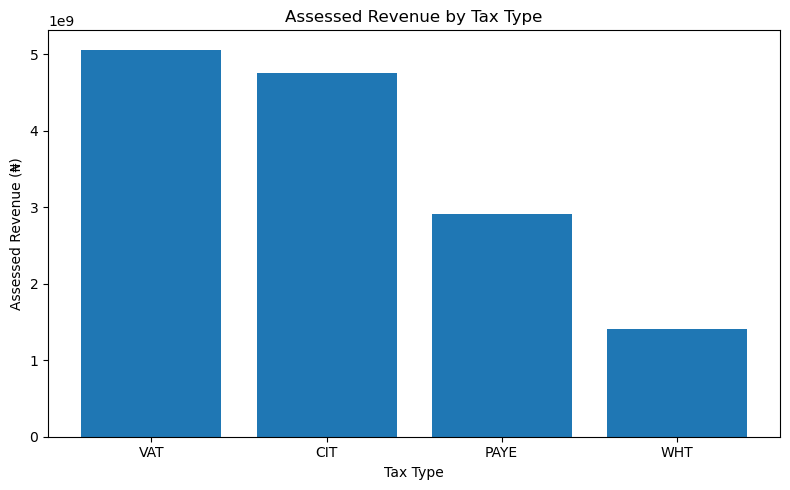

In [37]:
# ============================================================
# Revenue by Tax Type — Visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    revenue_by_tax["tax_type"],
    revenue_by_tax["Assessed_Revenue"]
)

plt.title("Assessed Revenue by Tax Type")
plt.xlabel("Tax Type")
plt.ylabel("Assessed Revenue (₦)")

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# 09.4 — Assessment vs Payment by Tax Type
# ============================================================

tax_comparison = revenue_by_tax[
    [
        "tax_type",
        "Assessed_Revenue",
        "Recorded_Payments",
        "Outstanding",
        "Payment_Ratio"
    ]
].copy()

display(tax_comparison)

,tax_type,Assessed_Revenue,Recorded_Payments,Outstanding,Payment_Ratio
2,VAT,5.060553e+09,2.035749e+09,3.024804e+09,40.23
0,CIT,4.759771e+09,1.913618e+09,2.846152e+09,40.20
1,PAYE,2.907233e+09,1.142292e+09,1.764941e+09,39.29
3,WHT,1.407103e+09,5.660716e+08,8.410317e+08,40.23


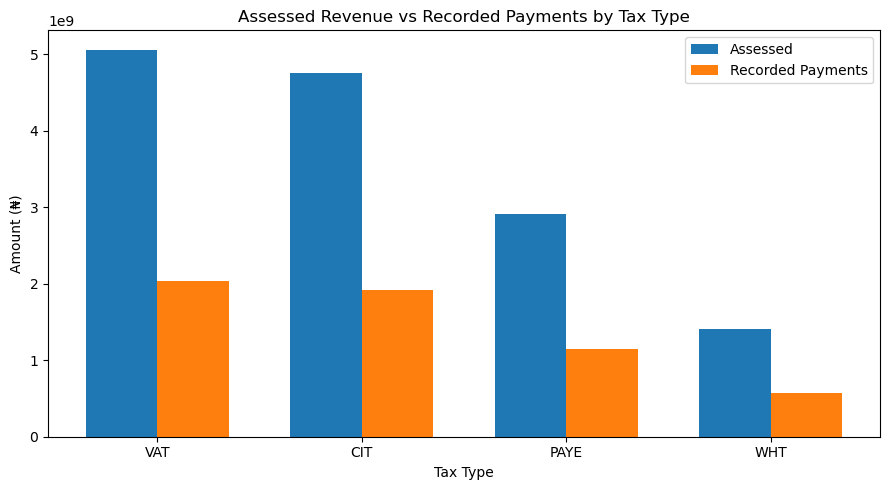

In [39]:
# ============================================================
# Assessment vs Payment Visualization
# ============================================================

x = np.arange(len(tax_comparison))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    tax_comparison["Assessed_Revenue"],
    width,
    label="Assessed"
)

plt.bar(
    x + width / 2,
    tax_comparison["Recorded_Payments"],
    width,
    label="Recorded Payments"
)

plt.xticks(x, tax_comparison["tax_type"])

plt.title("Assessed Revenue vs Recorded Payments by Tax Type")
plt.xlabel("Tax Type")
plt.ylabel("Amount (₦)")

plt.legend()

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# 09.5 — Revenue by Assessment Month
# ============================================================

assessment_position["assessment_month"] = (
    assessment_position["assessment_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    assessment_position
    .groupby("assessment_month")
    .agg(
        Assessments=("assessment_id", "nunique"),
        Assessed_Revenue=("assessed_amount", "sum"),
        Recorded_Payments=("total_paid", "sum")
    )
    .reset_index()
)

monthly_revenue["Outstanding"] = (
    monthly_revenue["Assessed_Revenue"] -
    monthly_revenue["Recorded_Payments"]
)

monthly_revenue["Payment_Ratio"] = (
    monthly_revenue["Recorded_Payments"] /
    monthly_revenue["Assessed_Revenue"] * 100
)

display(monthly_revenue.round(2))

,assessment_month,Assessments,Assessed_Revenue,Recorded_Payments,Outstanding,Payment_Ratio
0,2025-01,1330,7.551225e+08,3.169089e+08,4.382136e+08,41.97
1,2025-02,1219,6.689433e+08,2.778331e+08,3.911102e+08,41.53
2,2025-03,1379,8.103184e+08,3.454193e+08,4.648991e+08,42.63
3,2025-04,1242,7.024282e+08,2.707707e+08,4.316575e+08,38.55
4,2025-05,1357,7.611130e+08,3.211557e+08,4.399573e+08,42.20
5,2025-06,1353,7.103102e+08,2.791318e+08,4.311784e+08,39.30
6,2025-07,1367,7.860145e+08,3.096197e+08,4.763948e+08,39.39
7,2025-08,1328,7.816460e+08,3.261381e+08,4.555079e+08,41.72
8,2025-09,1242,7.115568e+08,2.793312e+08,4.322256e+08,39.26
9,2025-10,1280,7.242707e+08,2.894183e+08,4.348523e+08,39.96


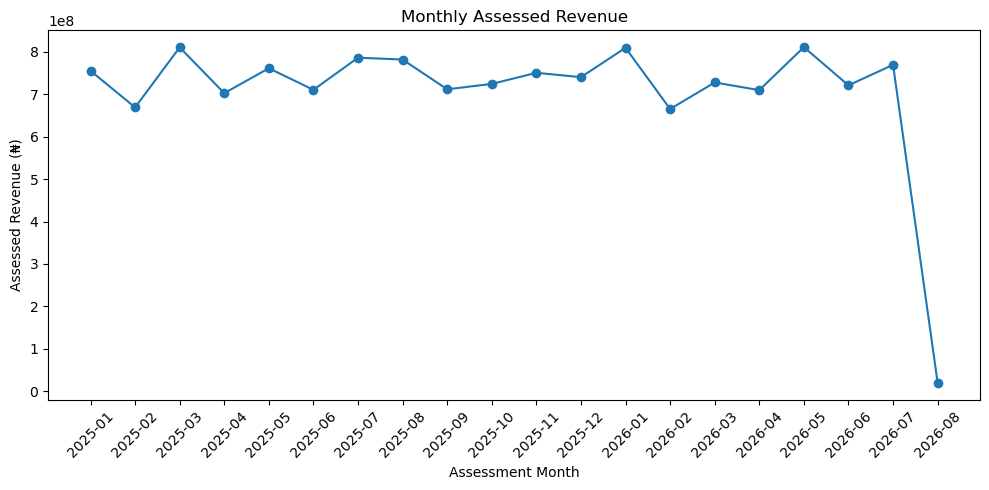

In [41]:
# ============================================================
# Monthly Assessed Revenue
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["assessment_month"],
    monthly_revenue["Assessed_Revenue"],
    marker="o"
)

plt.title("Monthly Assessed Revenue")
plt.xlabel("Assessment Month")
plt.ylabel("Assessed Revenue (₦)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 09.6 — Revenue Gap Analysis

The revenue gap analysis compares assessed liabilities with recorded payments to identify the largest absolute differences across tax types.

The gap should be interpreted as an assessment-to-payment difference rather than automatically as unpaid or recoverable revenue, because payment timing and reconciliation conditions identified during data validation may affect the relationship between assessment and payment records.

In [42]:
# ============================================================
# 09.6 — Revenue Gap Analysis
# ============================================================

revenue_gap = revenue_by_tax[
    [
        "tax_type",
        "Assessed_Revenue",
        "Recorded_Payments",
        "Outstanding",
        "Payment_Ratio"
    ]
].copy()

revenue_gap["Gap_Share"] = (
    revenue_gap["Outstanding"] /
    revenue_gap["Outstanding"].sum() * 100
)

revenue_gap = revenue_gap.sort_values(
    "Outstanding",
    ascending=False
)

display(revenue_gap.round(2))

,tax_type,Assessed_Revenue,Recorded_Payments,Outstanding,Payment_Ratio,Gap_Share
2,VAT,5.060553e+09,2.035749e+09,3.024804e+09,40.23,35.68
0,CIT,4.759771e+09,1.913618e+09,2.846152e+09,40.20,33.58
1,PAYE,2.907233e+09,1.142292e+09,1.764941e+09,39.29,20.82
3,WHT,1.407103e+09,5.660716e+08,8.410317e+08,40.23,9.92


In [43]:
# ============================================================
# 09.7 — Monthly Payment Performance
# ============================================================

monthly_performance = monthly_revenue.copy()

# Exclude the final partial month from comparative ranking
monthly_complete = monthly_performance[
    monthly_performance["assessment_month"] < "2026-08"
].copy()

monthly_complete = monthly_complete.sort_values(
    "Payment_Ratio",
    ascending=False
)

display(
    monthly_complete[
        [
            "assessment_month",
            "Assessments",
            "Assessed_Revenue",
            "Recorded_Payments",
            "Outstanding",
            "Payment_Ratio"
        ]
    ].round(2)
)

,assessment_month,Assessments,Assessed_Revenue,Recorded_Payments,Outstanding,Payment_Ratio
10,2025-11,1319,7.503861e+08,3.253402e+08,4.250458e+08,43.36
2,2025-03,1379,8.103184e+08,3.454193e+08,4.648991e+08,42.63
4,2025-05,1357,7.611130e+08,3.211557e+08,4.399573e+08,42.20
0,2025-01,1330,7.551225e+08,3.169089e+08,4.382136e+08,41.97
7,2025-08,1328,7.816460e+08,3.261381e+08,4.555079e+08,41.72
1,2025-02,1219,6.689433e+08,2.778331e+08,3.911102e+08,41.53
12,2026-01,1397,8.093260e+08,3.338088e+08,4.755172e+08,41.25
17,2026-06,1311,7.208360e+08,2.928889e+08,4.279471e+08,40.63
18,2026-07,1334,7.692710e+08,3.078597e+08,4.614113e+08,40.02
9,2025-10,1280,7.242707e+08,2.894183e+08,4.348523e+08,39.96


In [44]:
# ============================================================
# Strongest and Weakest Complete Months
# ============================================================

strongest_month = monthly_complete.loc[
    monthly_complete["Payment_Ratio"].idxmax()
]

weakest_month = monthly_complete.loc[
    monthly_complete["Payment_Ratio"].idxmin()
]

monthly_extremes = pd.DataFrame({
    "Performance": [
        "Strongest Complete Month",
        "Weakest Complete Month"
    ],
    "Month": [
        strongest_month["assessment_month"],
        weakest_month["assessment_month"]
    ],
    "Payment Ratio": [
        strongest_month["Payment_Ratio"],
        weakest_month["Payment_Ratio"]
    ]
})

display(monthly_extremes.round(2))

,Performance,Month,Payment Ratio
0,Strongest Complete Month,2025-11,43.36
1,Weakest Complete Month,2026-04,33.33


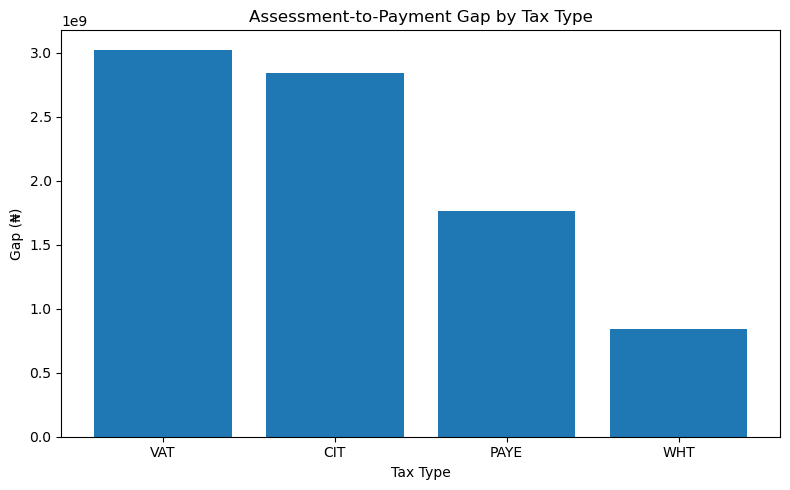

In [45]:
# ============================================================
# 09.8 — Revenue Gap by Tax Type
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    revenue_gap["tax_type"],
    revenue_gap["Outstanding"]
)

plt.title("Assessment-to-Payment Gap by Tax Type")
plt.xlabel("Tax Type")
plt.ylabel("Gap (₦)")

plt.tight_layout()
plt.show()

## Revenue Intelligence Summary

The analysis identifies a total assessed liability of approximately ₦14.13 billion against ₦5.66 billion in recorded payments, resulting in a 40.03% payment-to-assessment ratio.

Revenue is concentrated primarily in VAT and CIT, which together represent 69.47% of total assessed revenue. This concentration makes these two tax types particularly important to overall revenue performance.

Despite differences in revenue scale, payment-to-assessment ratios are relatively consistent across the four tax types, ranging from 39.29% for PAYE to 40.23% for VAT and WHT. This suggests that the principal revenue opportunity may not be limited to a single tax type.

Monthly payment performance also varies. November 2025 recorded the strongest payment-to-assessment ratio among complete months at 43.36%, while April 2026 recorded the lowest at 33.33%.

The assessment-to-payment difference should be treated as a revenue realization gap rather than automatically classified as unpaid tax. Earlier validation identified payment timing anomalies, zero-value transactions, and assessments with payments exceeding assessed liabilities. These conditions require reconciliation before the gap can be interpreted as recoverable revenue.

Overall, the revenue intelligence indicates a substantial opportunity to improve revenue realization, with particular attention warranted around the largest revenue pools and periods showing weaker payment performance.

# 10. Compliance Intelligence

Compliance intelligence examines taxpayer payment behavior against assessed tax liabilities.

The analysis focuses on payment status, outstanding exposure, payment completion, payment timing, and patterns of compliance across tax types.

The objective is not to label individual taxpayers as non-compliant solely from payment records. Instead, the analysis identifies measurable compliance signals and areas of potential revenue or reconciliation risk that may warrant further investigation.

All compliance indicators are derived from the validated assessment-level payment position established in Section 08.

In [46]:
# ============================================================
# 10.1 — Overall Compliance Position
# ============================================================

compliance_position = (
    assessment_position["payment_status"]
    .value_counts()
    .rename_axis("Payment Status")
    .reset_index(name="Assessments")
)

compliance_position["Percentage"] = round(
    compliance_position["Assessments"] /
    compliance_position["Assessments"].sum() * 100,
    2
)

display(compliance_position)

,Payment Status,Assessments,Percentage
0,No Payment Record,11242,44.97
1,Partially Paid,7867,31.47
2,Overpaid,3763,15.05
3,Zero-Value Payment,2128,8.51


In [47]:
# ============================================================
# 10.2 — Outstanding Revenue Exposure
# ============================================================

total_outstanding = assessment_position["outstanding_amount"].sum()

positive_outstanding = assessment_position.loc[
    assessment_position["outstanding_amount"] > 0,
    "outstanding_amount"
].sum()

overpaid_amount = assessment_position.loc[
    assessment_position["outstanding_amount"] < 0,
    "outstanding_amount"
].sum()

compliance_exposure = pd.DataFrame({
    "Metric": [
        "Total Assessment-Position Difference",
        "Positive Outstanding Exposure",
        "Overpayment Offset"
    ],
    "Amount": [
        total_outstanding,
        positive_outstanding,
        abs(overpaid_amount)
    ]
})

display(compliance_exposure.round(2))

,Metric,Amount
0,Total Assessment-Position Difference,8.476929e+09
1,Positive Outstanding Exposure,9.418204e+09
2,Overpayment Offset,9.412755e+08


In [48]:
# ============================================================
# 10.3 — Compliance Position by Tax Type
# ============================================================

compliance_by_tax = (
    assessment_position
    .groupby(["tax_type", "payment_status"])
    .agg(
        Assessments=("assessment_id", "nunique"),
        Assessed_Amount=("assessed_amount", "sum"),
        Total_Paid=("total_paid", "sum"),
        Outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

display(compliance_by_tax.round(2))

,tax_type,payment_status,Assessments,Assessed_Amount,Total_Paid,Outstanding
0,CIT,No Payment Record,2782,2.172894e+09,0.000000e+00,2.172894e+09
1,CIT,Overpaid,924,7.467961e+08,1.075434e+09,-3.286381e+08
2,CIT,Partially Paid,1928,1.466724e+09,8.381842e+08,6.285399e+08
3,CIT,Zero-Value Payment,517,3.733567e+08,0.000000e+00,3.733567e+08
4,PAYE,No Payment Record,2919,1.329148e+09,0.000000e+00,1.329148e+09
5,PAYE,Overpaid,942,4.458206e+08,6.413330e+08,-1.955125e+08
6,PAYE,Partially Paid,1949,9.037563e+08,5.009591e+08,4.027972e+08
7,PAYE,Zero-Value Payment,535,2.285089e+08,0.000000e+00,2.285089e+08
8,VAT,No Payment Record,3889,2.220611e+09,0.000000e+00,2.220611e+09
9,VAT,Overpaid,1304,7.697833e+08,1.099617e+09,-3.298333e+08


In [49]:
# ============================================================
# 10.4 — Potential Payment Exposure by Tax Type
# ============================================================

potential_exposure = (
    assessment_position[
        assessment_position["outstanding_amount"] > 0
    ]
    .groupby("tax_type")
    .agg(
        Assessments=("assessment_id", "nunique"),
        Assessed_Amount=("assessed_amount", "sum"),
        Recorded_Payments=("total_paid", "sum"),
        Outstanding_Exposure=("outstanding_amount", "sum")
    )
    .reset_index()
)

potential_exposure["Exposure_Rate"] = (
    potential_exposure["Outstanding_Exposure"] /
    potential_exposure["Assessed_Amount"] * 100
)

potential_exposure = potential_exposure.sort_values(
    "Outstanding_Exposure",
    ascending=False
)

display(potential_exposure.round(2))

,tax_type,Assessments,Assessed_Amount,Recorded_Payments,Outstanding_Exposure,Exposure_Rate
2,VAT,7368,4.290769e+09,9.361323e+08,3.354637e+09,78.18
0,CIT,5227,4.012975e+09,8.381842e+08,3.174791e+09,79.11
1,PAYE,5403,2.461413e+09,5.009591e+08,1.960454e+09,79.65
3,WHT,3239,1.193047e+09,2.647237e+08,9.283233e+08,77.81


In [50]:
# ============================================================
# 10.5 — Payment Timing by Tax Type
# ============================================================

timing_by_tax = (
    payment_validation
    .groupby("tax_type")
    .agg(
        Payment_Transactions=("payment_id", "count"),
        Before_Assessment=(
            "payment_timing_flag",
            lambda x: (x == "Before Assessment").sum()
        ),
        Same_Day=(
            "payment_timing_flag",
            lambda x: (x == "Same Day").sum()
        ),
        After_Assessment=(
            "payment_timing_flag",
            lambda x: (x == "After Assessment").sum()
        )
    )
    .reset_index()
)

timing_by_tax["Before_Assessment_%"] = round(
    timing_by_tax["Before_Assessment"] /
    timing_by_tax["Payment_Transactions"] * 100,
    2
)

display(timing_by_tax)

,tax_type,Payment_Transactions,Before_Assessment,Same_Day,After_Assessment,Before_Assessment_%
0,CIT,4863,1821,8,3034,37.45
1,PAYE,4964,1818,9,3137,36.62
2,VAT,6991,2613,7,4371,37.38
3,WHT,3192,1210,2,1980,37.91


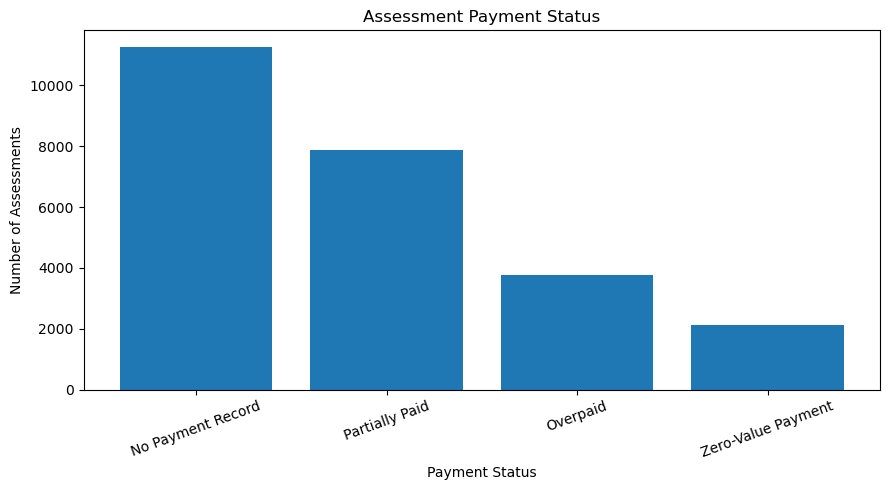

In [51]:
# ============================================================
# 10.6 — Compliance Status Visualization
# ============================================================

status_plot = compliance_position.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    status_plot["Payment Status"],
    status_plot["Assessments"]
)

plt.title("Assessment Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Assessments")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

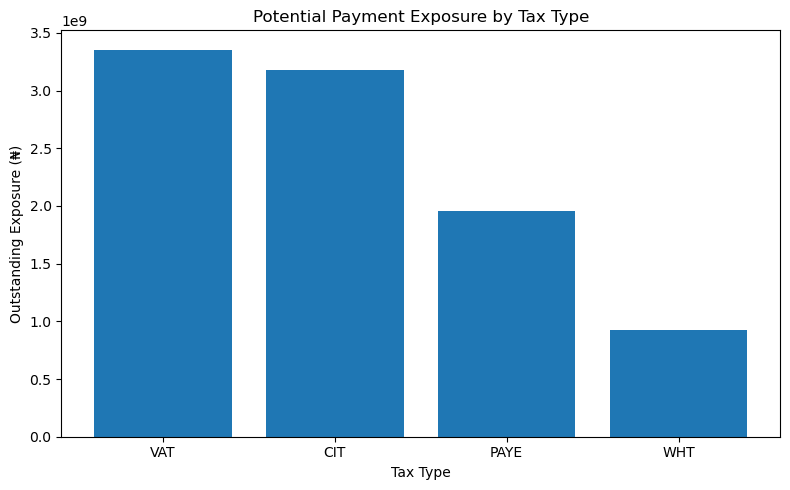

In [52]:
# ============================================================
# 10.7 — Outstanding Exposure by Tax Type
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    potential_exposure["tax_type"],
    potential_exposure["Outstanding_Exposure"]
)

plt.title("Potential Payment Exposure by Tax Type")
plt.xlabel("Tax Type")
plt.ylabel("Outstanding Exposure (₦)")

plt.tight_layout()
plt.show()

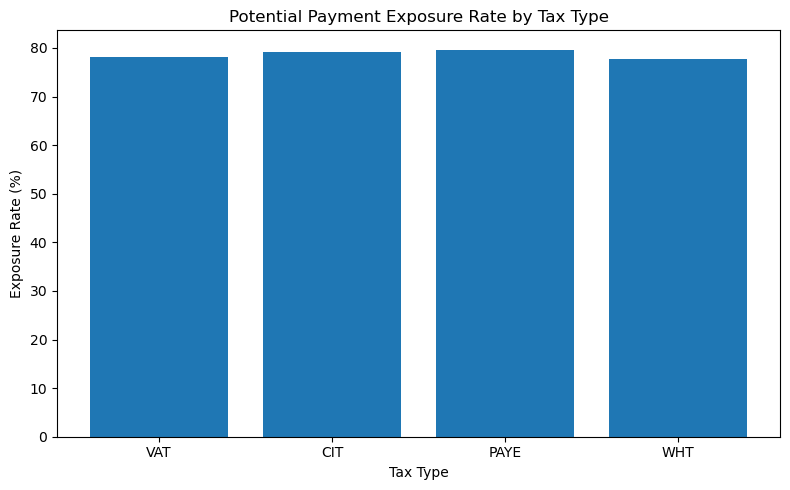

In [54]:
# ============================================================
# 10.8 — Exposure Rate by Tax Type
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    potential_exposure["tax_type"],
    potential_exposure["Exposure_Rate"]
)

plt.title("Potential Payment Exposure Rate by Tax Type")
plt.xlabel("Tax Type")
plt.ylabel("Exposure Rate (%)")

plt.tight_layout()
plt.show()

## Compliance Intelligence Summary

The compliance analysis indicates substantial payment exposure across the assessment portfolio. Of the 25,000 assessments analyzed, 44.97% have no payment record, 31.47% are partially paid, and 8.51% have payment records with zero financial value. A further 15.05% have recorded payments exceeding their assessed liabilities and therefore require reconciliation.

Positive outstanding exposure totals approximately ₦9.42 billion before accounting for overpayment offsets of approximately ₦941.28 million. The resulting net assessment-to-payment difference is approximately ₦8.48 billion.

Potential exposure is broadly distributed across the four tax types. Exposure rates range from 77.81% for WHT to 79.65% for PAYE, indicating that the observed payment gap is not concentrated in a single tax category.

Payment timing also shows a consistent pattern across tax types, with approximately 36.62%–37.91% of payment transactions occurring before their linked assessment dates. This consistency suggests that the timing condition may reflect a broader data or process characteristic rather than an isolated tax-type issue.

These findings should be treated as compliance and reconciliation signals rather than confirmed taxpayer non-compliance. Further investigation of assessment due dates, payment allocation, and taxpayer-level behavior is required before enforcement conclusions are drawn.

# 11. Taxpayer Intelligence

Taxpayer Intelligence examines the characteristics and distribution of registered taxpayers and connects taxpayer attributes with assessment and payment behavior.

The analysis focuses on taxpayer concentration by business size, sector, and taxpayer activity, while identifying segments that may have greater revenue or payment exposure.

The objective is to understand where taxpayer activity and compliance exposure are concentrated and provide evidence for more targeted revenue administration.

The analysis uses taxpayer-level information together with validated assessment and payment positions. Findings are presented at segment level and are not intended to classify individual taxpayers as compliant or non-compliant without further investigation.

In [55]:
# ============================================================
# 11.1 — Taxpayer Profile
# ============================================================

taxpayer_profile = pd.DataFrame({
    "Metric": [
        "Registered Taxpayers",
        "States Represented",
        "LGAs Represented",
        "Sectors Represented",
        "Business Size Categories"
    ],
    "Value": [
        taxpayers["taxpayer_id"].nunique(),
        taxpayers["state"].nunique(),
        taxpayers["lga"].nunique(),
        taxpayers["sector"].nunique(),
        taxpayers["business_size"].nunique()
    ]
})

display(taxpayer_profile)

,Metric,Value
0,Registered Taxpayers,10000
1,States Represented,8
2,LGAs Represented,40
3,Sectors Represented,9
4,Business Size Categories,4


In [56]:
# ============================================================
# 11.2 — Taxpayers by Business Size
# ============================================================

taxpayer_size = (
    taxpayers
    .groupby("business_size")
    .agg(
        Taxpayers=("taxpayer_id", "nunique")
    )
    .reset_index()
)

taxpayer_size["Share"] = (
    taxpayer_size["Taxpayers"] /
    taxpayer_size["Taxpayers"].sum() * 100
)

taxpayer_size = taxpayer_size.sort_values(
    "Taxpayers",
    ascending=False
)

display(taxpayer_size.round(2))

,business_size,Taxpayers,Share
3,Small,3512,35.12
1,Medium,2526,25.26
2,Micro,2464,24.64
0,Large,1498,14.98


In [57]:
# ============================================================
# 11.3 — Taxpayers by Sector
# ============================================================

taxpayer_sector = (
    taxpayers
    .groupby("sector")
    .agg(
        Taxpayers=("taxpayer_id", "nunique")
    )
    .reset_index()
)

taxpayer_sector["Share"] = (
    taxpayer_sector["Taxpayers"] /
    taxpayer_sector["Taxpayers"].sum() * 100
)

taxpayer_sector = taxpayer_sector.sort_values(
    "Taxpayers",
    ascending=False
)

display(taxpayer_sector.round(2))

,sector,Taxpayers,Share
6,Professional Services,1313,13.13
4,Manufacturing,1310,13.10
7,Retail,1219,12.19
3,ICT,1192,11.92
5,Other Services,1120,11.20
1,Construction,1032,10.32
0,Agriculture,997,9.97
8,Transport,990,9.90
2,Hospitality,827,8.27


In [58]:
# ============================================================
# 11.4 — Taxpayer Assessment Activity
# ============================================================

assessed_taxpayers = assessments["taxpayer_id"].nunique()
registered_taxpayers = taxpayers["taxpayer_id"].nunique()

taxpayer_activity = pd.DataFrame({
    "Metric": [
        "Registered Taxpayers",
        "Taxpayers with Assessments",
        "Taxpayers without Assessments"
    ],
    "Count": [
        registered_taxpayers,
        assessed_taxpayers,
        registered_taxpayers - assessed_taxpayers
    ]
})

taxpayer_activity["Percentage"] = (
    taxpayer_activity["Count"] /
    registered_taxpayers * 100
)

display(taxpayer_activity.round(2))

,Metric,Count,Percentage
0,Registered Taxpayers,10000,100.00
1,Taxpayers with Assessments,9175,91.75
2,Taxpayers without Assessments,825,8.25


In [59]:
# ============================================================
# 11.5 — Taxpayer Revenue Contribution
# ============================================================

taxpayer_revenue = (
    assessments
    .groupby("taxpayer_id")
    .agg(
        Assessments=("assessment_id", "nunique"),
        Assessed_Revenue=("assessed_amount", "sum")
    )
    .reset_index()
)

taxpayer_revenue = taxpayer_revenue.merge(
    taxpayers[
        [
            "taxpayer_id",
            "state",
            "lga",
            "sector",
            "business_size"
        ]
    ],
    on="taxpayer_id",
    how="left"
)

display(taxpayer_revenue.head(10))

,taxpayer_id,Assessments,Assessed_Revenue,state,lga,sector,business_size
0,TP000001,2,1159120.23,FCT,Kwali,ICT,Medium
1,TP000002,2,423358.83,Kaduna,Igabi,Hospitality,Micro
2,TP000004,1,122622.74,Kwara,Moro,Retail,Small
3,TP000005,1,401874.25,FCT,Gwagwalada,Retail,Micro
4,TP000006,1,533935.70,Lagos,Surulere,Other Services,Micro
5,TP000007,4,1176257.20,Rivers,Ikwerre,Manufacturing,Small
6,TP000008,1,173557.79,Kwara,Ilorin West,Retail,Small
7,TP000010,2,715427.97,Lagos,Epe,Professional Services,Large
8,TP000012,1,471578.42,Enugu,Nkanu West,Hospitality,Small
9,TP000013,1,123089.51,Kaduna,Zaria,Retail,Micro


In [60]:
# ============================================================
# 11.6 — Revenue by Business Size
# ============================================================

revenue_by_size = (
    taxpayer_revenue
    .groupby("business_size")
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessments=("Assessments", "sum"),
        Assessed_Revenue=("Assessed_Revenue", "sum")
    )
    .reset_index()
)

revenue_by_size["Revenue_Share"] = (
    revenue_by_size["Assessed_Revenue"] /
    revenue_by_size["Assessed_Revenue"].sum() * 100
)

revenue_by_size = revenue_by_size.sort_values(
    "Assessed_Revenue",
    ascending=False
)

display(revenue_by_size.round(2))

,business_size,Taxpayers,Assessments,Assessed_Revenue,Revenue_Share
0,Large,1377,3773,4.781058e+09,33.83
1,Medium,2321,6352,4.380492e+09,30.99
3,Small,3222,8761,3.444912e+09,24.37
2,Micro,2255,6114,1.528199e+09,10.81


In [61]:
# ============================================================
# 11.7 — Revenue by Sector
# ============================================================

revenue_by_sector = (
    taxpayer_revenue
    .groupby("sector")
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessments=("Assessments", "sum"),
        Assessed_Revenue=("Assessed_Revenue", "sum")
    )
    .reset_index()
)

revenue_by_sector["Revenue_Share"] = (
    revenue_by_sector["Assessed_Revenue"] /
    revenue_by_sector["Assessed_Revenue"].sum() * 100
)

revenue_by_sector = revenue_by_sector.sort_values(
    "Assessed_Revenue",
    ascending=False
)

display(revenue_by_sector.round(2))

,sector,Taxpayers,Assessments,Assessed_Revenue,Revenue_Share
6,Professional Services,1212,3268,1.888766e+09,13.36
4,Manufacturing,1210,3297,1.789164e+09,12.66
7,Retail,1118,3015,1.739306e+09,12.31
3,ICT,1101,2993,1.663160e+09,11.77
5,Other Services,1011,2731,1.528278e+09,10.81
1,Construction,940,2624,1.506533e+09,10.66
8,Transport,900,2508,1.431862e+09,10.13
0,Agriculture,920,2551,1.408838e+09,9.97
2,Hospitality,763,2013,1.178754e+09,8.34


In [62]:
# ============================================================
# 11.8 — Taxpayer Payment Behavior
# ============================================================

taxpayer_compliance = (
    assessment_position
    .groupby("taxpayer_id")
    .agg(
        Assessments=("assessment_id", "nunique"),
        Assessed_Amount=("assessed_amount", "sum"),
        Total_Paid=("total_paid", "sum"),
        Outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

taxpayer_compliance["Payment_Ratio"] = (
    taxpayer_compliance["Total_Paid"] /
    taxpayer_compliance["Assessed_Amount"] * 100
)

taxpayer_compliance = taxpayer_compliance.merge(
    taxpayers[
        [
            "taxpayer_id",
            "state",
            "lga",
            "sector",
            "business_size"
        ]
    ],
    on="taxpayer_id",
    how="left"
)

display(taxpayer_compliance.head(10).round(2))

,taxpayer_id,Assessments,Assessed_Amount,Total_Paid,Outstanding,Payment_Ratio,state,lga,sector,business_size
0,TP000001,2,1159120.23,0.00,1159120.23,0.00,FCT,Kwali,ICT,Medium
1,TP000002,2,423358.83,589566.32,-166207.49,139.26,Kaduna,Igabi,Hospitality,Micro
2,TP000004,1,122622.74,0.00,122622.74,0.00,Kwara,Moro,Retail,Small
3,TP000005,1,401874.25,215442.74,186431.51,53.61,FCT,Gwagwalada,Retail,Micro
4,TP000006,1,533935.70,806854.31,-272918.61,151.11,Lagos,Surulere,Other Services,Micro
5,TP000007,4,1176257.20,705416.92,470840.28,59.97,Rivers,Ikwerre,Manufacturing,Small
6,TP000008,1,173557.79,72755.36,100802.43,41.92,Kwara,Ilorin West,Retail,Small
7,TP000010,2,715427.97,132360.66,583067.31,18.50,Lagos,Epe,Professional Services,Large
8,TP000012,1,471578.42,412540.43,59037.99,87.48,Enugu,Nkanu West,Hospitality,Small
9,TP000013,1,123089.51,115801.66,7287.85,94.08,Kaduna,Zaria,Retail,Micro


In [63]:
# ============================================================
# 11.9 — Compliance Exposure by Business Size
# ============================================================

exposure_by_size = (
    taxpayer_compliance
    .groupby("business_size")
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessed_Amount=("Assessed_Amount", "sum"),
        Total_Paid=("Total_Paid", "sum"),
        Outstanding_Exposure=("Outstanding", lambda x: x[x > 0].sum())
    )
    .reset_index()
)

exposure_by_size["Exposure_Rate"] = (
    exposure_by_size["Outstanding_Exposure"] /
    exposure_by_size["Assessed_Amount"] * 100
)

exposure_by_size = exposure_by_size.sort_values(
    "Outstanding_Exposure",
    ascending=False
)

display(exposure_by_size.round(2))

,business_size,Taxpayers,Assessed_Amount,Total_Paid,Outstanding_Exposure,Exposure_Rate
0,Large,1377,4.781058e+09,1.935397e+09,2.951923e+09,61.74
1,Medium,2321,4.380492e+09,1.743294e+09,2.750331e+09,62.79
3,Small,3222,3.444912e+09,1.377147e+09,2.153091e+09,62.50
2,Micro,2255,1.528199e+09,6.018931e+08,9.601991e+08,62.83


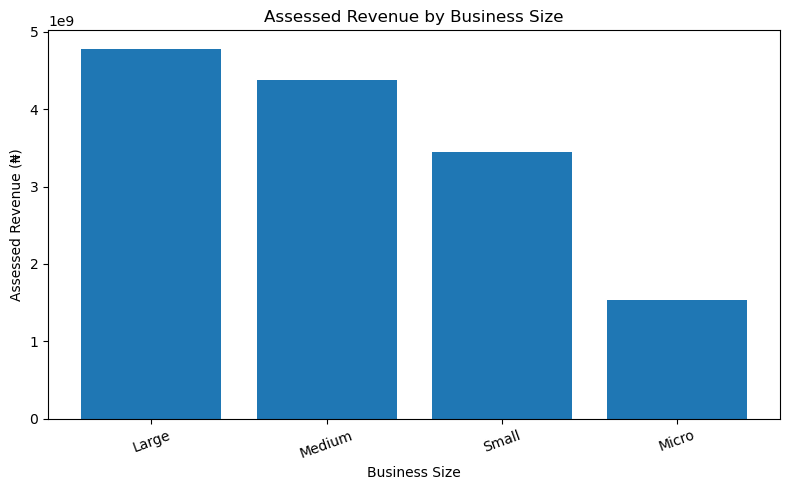

In [64]:
# ============================================================
# 11.10 — Revenue by Business Size Visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    revenue_by_size["business_size"],
    revenue_by_size["Assessed_Revenue"]
)

plt.title("Assessed Revenue by Business Size")
plt.xlabel("Business Size")
plt.ylabel("Assessed Revenue (₦)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

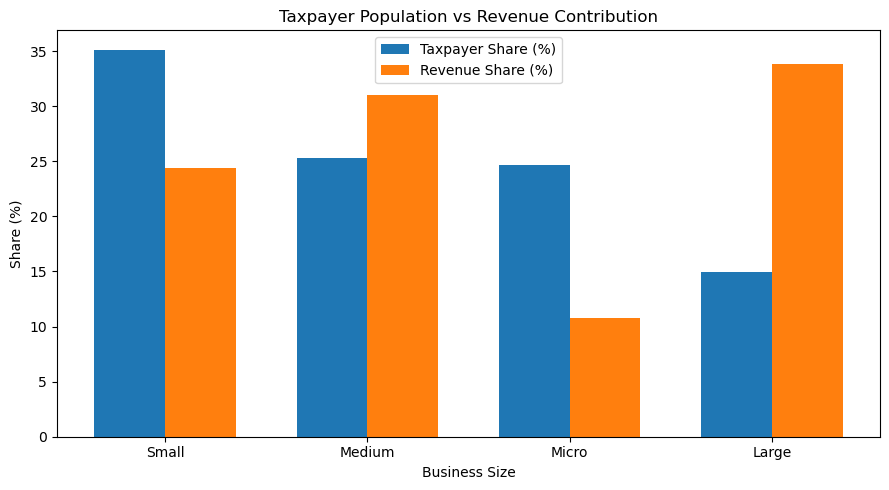

In [65]:
# ============================================================
# 11.11 — Taxpayer Concentration vs Revenue Contribution
# ============================================================

size_comparison = taxpayer_size.merge(
    revenue_by_size[
        ["business_size", "Revenue_Share"]
    ],
    on="business_size",
    how="left"
)

x = np.arange(len(size_comparison))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    size_comparison["Share"],
    width,
    label="Taxpayer Share (%)"
)

plt.bar(
    x + width / 2,
    size_comparison["Revenue_Share"],
    width,
    label="Revenue Share (%)"
)

plt.title("Taxpayer Population vs Revenue Contribution")
plt.xlabel("Business Size")
plt.ylabel("Share (%)")

plt.xticks(x, size_comparison["business_size"])
plt.legend()

plt.tight_layout()
plt.show()

## Taxpayer Intelligence Summary

The taxpayer population comprises 10,000 registered taxpayers distributed across 8 states, 40 LGAs, 9 economic sectors, and 4 business-size categories. A total of 9,175 taxpayers, representing 91.75% of the registered population, have assessment records in the dataset.

Small businesses form the largest taxpayer segment, accounting for 35.12% of registered taxpayers. However, taxpayer population size does not correspond directly with revenue contribution. Large taxpayers represent only 14.98% of the taxpayer population but account for 33.83% of assessed revenue, while large and medium taxpayers together represent 40.24% of taxpayers but contribute 64.82% of assessed revenue.

Payment exposure is relatively consistent across business-size segments, ranging from 61.74% for large taxpayers to 62.83% for micro taxpayers. This suggests that payment exposure is not concentrated within a single business-size category, although the financial impact is greater among higher-value taxpayer segments.

Assessed revenue is also broadly distributed across economic sectors. Professional Services, Manufacturing, Retail, and ICT are the largest sector contributors, but no single sector dominates the revenue base.

Overall, taxpayer intelligence indicates that taxpayer population size and revenue contribution are not proportional. This supports a segmented revenue-administration approach that considers both taxpayer volume and financial significance rather than relying on taxpayer counts alone.

# 12. Geographic Intelligence

Geographic Intelligence examines the distribution of taxpayers, assessed revenue, recorded payments, and payment exposure across states and Local Government Areas (LGAs).

The objective is to identify geographic concentrations of revenue activity and potential payment exposure that may support targeted revenue administration, monitoring, and resource allocation.

Geographic differences are interpreted as portfolio-level patterns rather than evidence of taxpayer behavior or compliance at the individual level.

In [66]:
# ============================================================
# 12.1 — Geographic Coverage
# ============================================================

geographic_profile = pd.DataFrame({
    "Metric": [
        "States",
        "LGAs",
        "Taxpayers"
    ],
    "Value": [
        taxpayers["state"].nunique(),
        taxpayers["lga"].nunique(),
        taxpayers["taxpayer_id"].nunique()
    ]
})

display(geographic_profile)

,Metric,Value
0,States,8
1,LGAs,40
2,Taxpayers,10000


In [67]:
# ============================================================
# 12.2 — Taxpayer Distribution by State
# ============================================================

taxpayers_by_state = (
    taxpayers
    .groupby("state")
    .agg(
        Taxpayers=("taxpayer_id", "nunique")
    )
    .reset_index()
)

taxpayers_by_state["Taxpayer_Share"] = (
    taxpayers_by_state["Taxpayers"] /
    taxpayers_by_state["Taxpayers"].sum() * 100
)

taxpayers_by_state = taxpayers_by_state.sort_values(
    "Taxpayers",
    ascending=False
)

display(taxpayers_by_state.round(2))

,state,Taxpayers,Taxpayer_Share
5,Lagos,1959,19.59
3,Kano,1446,14.46
2,Kaduna,1237,12.37
7,Rivers,1203,12.03
1,FCT,1161,11.61
4,Kwara,1032,10.32
0,Enugu,997,9.97
6,Ogun,965,9.65


In [68]:
# ============================================================
# 12.3 — Assessed Revenue by State
# ============================================================

revenue_by_state = (
    taxpayer_revenue
    .groupby("state")
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessments=("Assessments", "sum"),
        Assessed_Revenue=("Assessed_Revenue", "sum")
    )
    .reset_index()
)

revenue_by_state["Revenue_Share"] = (
    revenue_by_state["Assessed_Revenue"] /
    revenue_by_state["Assessed_Revenue"].sum() * 100
)

revenue_by_state = revenue_by_state.sort_values(
    "Assessed_Revenue",
    ascending=False
)

display(revenue_by_state.round(2))

,state,Taxpayers,Assessments,Assessed_Revenue,Revenue_Share
5,Lagos,1801,4887,2.741145e+09,19.39
3,Kano,1320,3645,2.024984e+09,14.33
2,Kaduna,1139,3089,1.708454e+09,12.09
7,Rivers,1103,2967,1.695261e+09,11.99
1,FCT,1072,2972,1.695081e+09,11.99
4,Kwara,941,2589,1.441191e+09,10.20
0,Enugu,919,2462,1.430766e+09,10.12
6,Ogun,880,2389,1.397777e+09,9.89


In [69]:
# ============================================================
# 12.4 — Payment Exposure by State
# ============================================================

state_exposure = (
    taxpayer_compliance
    .groupby("state")
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessed_Amount=("Assessed_Amount", "sum"),
        Total_Paid=("Total_Paid", "sum"),
        Outstanding_Exposure=(
            "Outstanding",
            lambda x: x[x > 0].sum()
        )
    )
    .reset_index()
)

state_exposure["Exposure_Rate"] = (
    state_exposure["Outstanding_Exposure"] /
    state_exposure["Assessed_Amount"] * 100
)

state_exposure = state_exposure.sort_values(
    "Outstanding_Exposure",
    ascending=False
)

display(state_exposure.round(2))

,state,Taxpayers,Assessed_Amount,Total_Paid,Outstanding_Exposure,Exposure_Rate
5,Lagos,1801,2.741145e+09,1.090941e+09,1.712375e+09,62.47
3,Kano,1320,2.024984e+09,8.409773e+08,1.235093e+09,60.99
1,FCT,1072,1.695081e+09,6.622959e+08,1.070322e+09,63.14
2,Kaduna,1139,1.708454e+09,7.169384e+08,1.035353e+09,60.60
7,Rivers,1103,1.695261e+09,7.404411e+08,1.009290e+09,59.54
6,Ogun,880,1.397777e+09,4.918678e+08,9.268036e+08,66.31
4,Kwara,941,1.441191e+09,5.594042e+08,9.150440e+08,63.49
0,Enugu,919,1.430766e+09,5.548655e+08,9.112630e+08,63.69


In [70]:
# ============================================================
# 12.5 — State Revenue & Exposure Summary
# ============================================================

state_summary = revenue_by_state[
    [
        "state",
        "Taxpayers",
        "Assessments",
        "Assessed_Revenue",
        "Revenue_Share"
    ]
].merge(
    state_exposure[
        [
            "state",
            "Total_Paid",
            "Outstanding_Exposure",
            "Exposure_Rate"
        ]
    ],
    on="state",
    how="left"
)

state_summary = state_summary.sort_values(
    "Assessed_Revenue",
    ascending=False
)

display(state_summary.round(2))

,state,Taxpayers,Assessments,Assessed_Revenue,Revenue_Share,Total_Paid,Outstanding_Exposure,Exposure_Rate
0,Lagos,1801,4887,2.741145e+09,19.39,1.090941e+09,1.712375e+09,62.47
1,Kano,1320,3645,2.024984e+09,14.33,8.409773e+08,1.235093e+09,60.99
2,Kaduna,1139,3089,1.708454e+09,12.09,7.169384e+08,1.035353e+09,60.60
3,Rivers,1103,2967,1.695261e+09,11.99,7.404411e+08,1.009290e+09,59.54
4,FCT,1072,2972,1.695081e+09,11.99,6.622959e+08,1.070322e+09,63.14
5,Kwara,941,2589,1.441191e+09,10.20,5.594042e+08,9.150440e+08,63.49
6,Enugu,919,2462,1.430766e+09,10.12,5.548655e+08,9.112630e+08,63.69
7,Ogun,880,2389,1.397777e+09,9.89,4.918678e+08,9.268036e+08,66.31


In [71]:
# ============================================================
# 12.6 — Revenue by LGA
# ============================================================

revenue_by_lga = (
    taxpayer_revenue
    .groupby(["state", "lga"])
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessments=("Assessments", "sum"),
        Assessed_Revenue=("Assessed_Revenue", "sum")
    )
    .reset_index()
)

revenue_by_lga["Revenue_Share"] = (
    revenue_by_lga["Assessed_Revenue"] /
    revenue_by_lga["Assessed_Revenue"].sum() * 100
)

revenue_by_lga = revenue_by_lga.sort_values(
    "Assessed_Revenue",
    ascending=False
)

display(revenue_by_lga.head(15).round(2))

,state,lga,Taxpayers,Assessments,Assessed_Revenue,Revenue_Share
29,Lagos,Surulere,386,1086,6.389748e+08,4.52
28,Lagos,Lagos Island,354,967,6.038642e+08,4.27
26,Lagos,Epe,366,991,5.022161e+08,3.55
27,Lagos,Ikeja,350,921,4.985917e+08,3.53
25,Lagos,Alimosho,345,922,4.974987e+08,3.52
17,Kano,Kano Municipal,276,778,4.366308e+08,3.09
19,Kano,Tarauni,254,700,4.206823e+08,2.98
16,Kano,Fagge,264,723,3.988046e+08,2.82
15,Kano,Dala,275,760,3.918621e+08,2.77
14,Kaduna,Zaria,249,690,3.858721e+08,2.73


In [72]:
# ============================================================
# 12.7 — LGA Payment Exposure
# ============================================================

lga_exposure = (
    taxpayer_compliance
    .groupby(["state", "lga"])
    .agg(
        Taxpayers=("taxpayer_id", "nunique"),
        Assessed_Amount=("Assessed_Amount", "sum"),
        Total_Paid=("Total_Paid", "sum"),
        Outstanding_Exposure=(
            "Outstanding",
            lambda x: x[x > 0].sum()
        )
    )
    .reset_index()
)

lga_exposure["Exposure_Rate"] = (
    lga_exposure["Outstanding_Exposure"] /
    lga_exposure["Assessed_Amount"] * 100
)

lga_exposure = lga_exposure.sort_values(
    "Outstanding_Exposure",
    ascending=False
)

display(lga_exposure.head(15).round(2))

,state,lga,Taxpayers,Assessed_Amount,Total_Paid,Outstanding_Exposure,Exposure_Rate
29,Lagos,Surulere,386,6.389748e+08,2.470342e+08,4.008026e+08,62.73
28,Lagos,Lagos Island,354,6.038642e+08,2.477799e+08,3.757677e+08,62.23
27,Lagos,Ikeja,350,4.985917e+08,2.002148e+08,3.131579e+08,62.81
26,Lagos,Epe,366,5.022161e+08,1.958068e+08,3.127333e+08,62.27
25,Lagos,Alimosho,345,4.974987e+08,2.001054e+08,3.099139e+08,62.29
17,Kano,Kano Municipal,276,4.366308e+08,1.746245e+08,2.702092e+08,61.89
16,Kano,Fagge,264,3.988046e+08,1.531055e+08,2.569930e+08,64.44
19,Kano,Tarauni,254,4.206823e+08,1.860182e+08,2.482254e+08,59.01
15,Kano,Dala,275,3.918621e+08,1.645289e+08,2.368876e+08,60.45
7,FCT,Gwagwalada,210,3.628769e+08,1.322270e+08,2.367028e+08,65.23


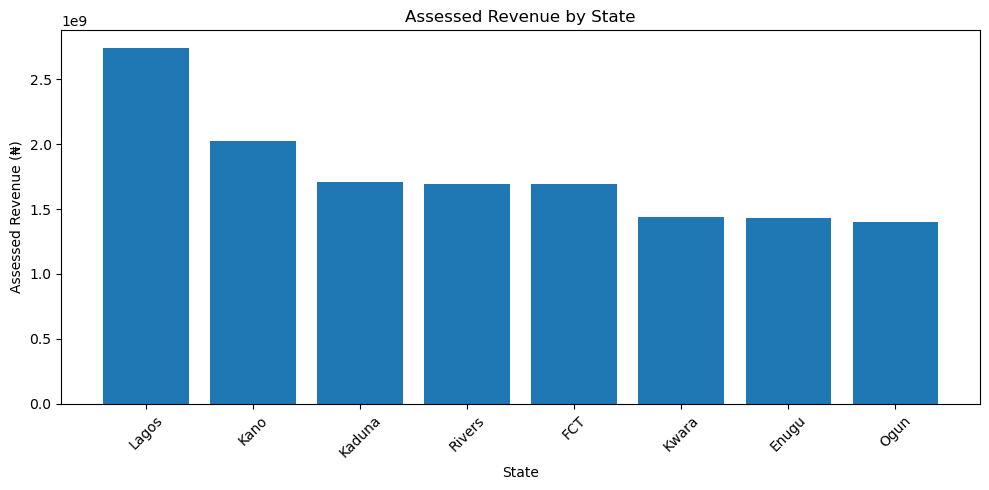

In [73]:
# ============================================================
# 12.8 — Revenue by State Visualization
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    revenue_by_state["state"],
    revenue_by_state["Assessed_Revenue"]
)

plt.title("Assessed Revenue by State")
plt.xlabel("State")
plt.ylabel("Assessed Revenue (₦)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

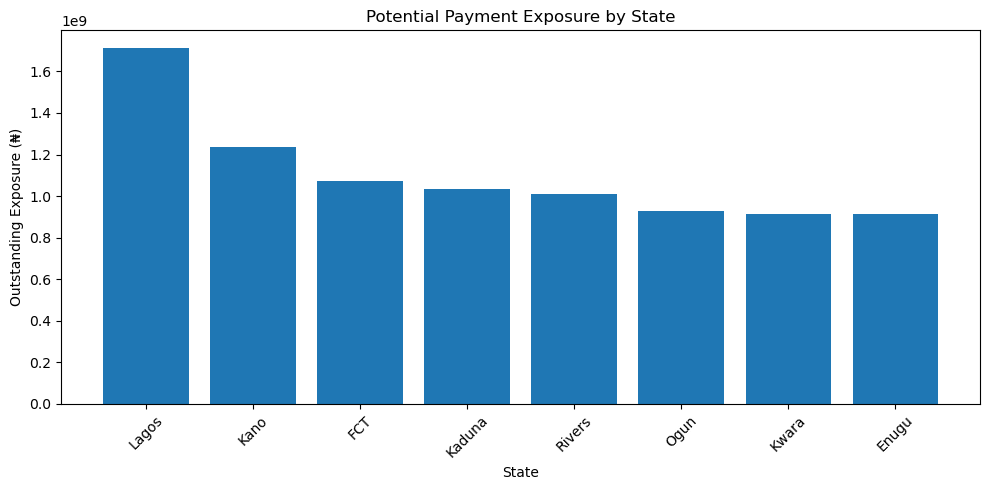

In [74]:
# ============================================================
# 12.9 — Payment Exposure by State Visualization
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    state_exposure["state"],
    state_exposure["Outstanding_Exposure"]
)

plt.title("Potential Payment Exposure by State")
plt.xlabel("State")
plt.ylabel("Outstanding Exposure (₦)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [75]:
# ============================================================
# 12.10 — High-Value Geographic Concentration
# ============================================================

geographic_priority = state_summary.copy()

geographic_priority["Revenue_Rank"] = (
    geographic_priority["Assessed_Revenue"]
    .rank(method="min", ascending=False)
)

geographic_priority["Exposure_Rank"] = (
    geographic_priority["Outstanding_Exposure"]
    .rank(method="min", ascending=False)
)

geographic_priority["Priority_Score"] = (
    geographic_priority["Revenue_Rank"] +
    geographic_priority["Exposure_Rank"]
)

geographic_priority = geographic_priority.sort_values(
    "Priority_Score"
)

display(
    geographic_priority[
        [
            "state",
            "Assessed_Revenue",
            "Revenue_Share",
            "Outstanding_Exposure",
            "Exposure_Rate",
            "Revenue_Rank",
            "Exposure_Rank"
        ]
    ].round(2)
)

,state,Assessed_Revenue,Revenue_Share,Outstanding_Exposure,Exposure_Rate,Revenue_Rank,Exposure_Rank
0,Lagos,2.741145e+09,19.39,1.712375e+09,62.47,1.0,1.0
1,Kano,2.024984e+09,14.33,1.235093e+09,60.99,2.0,2.0
2,Kaduna,1.708454e+09,12.09,1.035353e+09,60.60,3.0,4.0
4,FCT,1.695081e+09,11.99,1.070322e+09,63.14,5.0,3.0
3,Rivers,1.695261e+09,11.99,1.009290e+09,59.54,4.0,5.0
5,Kwara,1.441191e+09,10.20,9.150440e+08,63.49,6.0,7.0
7,Ogun,1.397777e+09,9.89,9.268036e+08,66.31,8.0,6.0
6,Enugu,1.430766e+09,10.12,9.112630e+08,63.69,7.0,8.0


### Geographic Intelligence Summary

The geographic analysis shows that tax revenue is concentrated across a small number of high-value states, while collection exposure varies materially across locations.

**Lagos** is the largest revenue market, contributing **₦2.74 billion (19.39%)** of assessed revenue and carrying the largest outstanding exposure of approximately **₦1.71 billion**. This makes Lagos the most significant geographic priority in absolute revenue terms.

**Kano** ranks second, contributing **14.33%** of assessed revenue with an outstanding exposure of approximately **₦1.24 billion**. Together, Lagos and Kano account for approximately one-third of total assessed revenue.

**FCT and Rivers** have similar assessed revenue shares of approximately **12%**, but their collection exposure differs considerably. Rivers has the lowest exposure rate among the eight states at **59.54%**, while FCT records **63.14%**, indicating a comparatively larger collection gap.

**Ogun** presents the highest exposure rate at **66.31%**, despite contributing only **9.89%** of assessed revenue. This suggests that geographic prioritisation should not be based solely on revenue size; collection performance must also be considered.

At the LGA level, **Surulere, Lagos Island, Epe, Ikeja and Alimosho** are among the largest revenue-generating locations, while several LGAs show exposure rates above 65%. These locations provide opportunities for more targeted taxpayer engagement and collection monitoring.

Overall, the geographic analysis indicates two distinct priorities:

- **High-value recovery:** Focus on locations with large outstanding amounts, particularly Lagos and Kano.
- **High-exposure intervention:** Investigate locations with comparatively high exposure rates, particularly Ogun and selected LGAs.

This supports a more targeted compliance strategy in which enforcement and taxpayer engagement are prioritised according to both **revenue value and collection exposure**.

> **Geographic Takeaway:** Revenue concentration and compliance exposure do not always occur in the same locations. Lagos represents the largest absolute recovery opportunity, while Ogun presents the highest relative exposure. Effective revenue administration should therefore combine **revenue size, outstanding exposure and exposure rate** when determining geographic priorities.

# 13 — AI-Powered Insights

## Insight Matrix

| Priority | AI-Powered Business Insight | Evidence from Analysis | Business Implication |
|---|---|---|---|
| **High** | **Payment realization is the primary revenue challenge.** | Total assessed revenue is **₦14.13bn**, while recorded payments are **₦5.66bn**, representing a payment-to-assessment ratio of approximately **40.03%**. | A substantial portion of assessed liabilities remains unrealized, creating significant collection opportunity. |
| **High** | **Outstanding exposure is concentrated across all major tax types.** | Overall positive outstanding exposure is approximately **₦9.42bn**. VAT and CIT account for the largest assessed-revenue bases and therefore represent major collection opportunities. | Recovery strategies should prioritize high-value outstanding liabilities while maintaining coverage across PAYE and WHT. |
| **High** | **Non-payment represents the largest compliance concern.** | **11,242 assessments (44.97%)** have no payment record, while another **2,128 (8.51%)** contain zero-value payment records. | Nearly half of assessments have no recorded payment, indicating a need for targeted compliance follow-up and payment monitoring. |
| **High** | **Payment timing contains a significant data and process-control signal.** | **7,462 payments (37.29%)** were recorded before their associated assessment date. | The pattern requires validation of business processes, posting dates, prepayments, adjustments, or possible data-recording issues before being interpreted as taxpayer non-compliance. |
| **Medium** | **Overpayments require reconciliation.** | **3,763 assessments (15.05%)** show payments exceeding assessed amounts, with approximately **₦941.28m** in excess payments. | Overpayments may represent credits, advance payments, reallocations, refunds, or reconciliation issues and should not automatically be treated as additional revenue. |
| **Medium** | **Revenue is geographically concentrated.** | Lagos contributes **19.39%** of assessed revenue, followed by Kano (**14.33%**) and Kaduna (**12.09%**). | Collection strategies should combine high-value recovery in major revenue centres with targeted interventions in high-exposure states. |
| **Medium** | **Ogun has the highest state-level exposure rate.** | Ogun records an exposure rate of **66.31%**, compared with **59.54%** in Rivers. | Ogun may require stronger collection and compliance intervention despite having a smaller assessed-revenue base than Lagos or Kano. |
| **Medium** | **Large taxpayers contribute disproportionately to assessed revenue.** | Large businesses represent only **14.98%** of registered taxpayers but account for **33.83%** of assessed revenue. | Large taxpayers should receive focused account-management and high-value arrears monitoring. |
| **Medium** | **Small businesses form the largest taxpayer population.** | Small businesses represent **35.12%** of registered taxpayers but contribute **24.37%** of assessed revenue. | Small-business compliance programmes should emphasize scalable education, filing support, and low-cost digital enforcement. |
| **Opportunity** | **The dataset identifies taxpayers outside the assessment cycle.** | **825 taxpayers (8.25%)** have no recorded assessments. | These taxpayers provide a potential discovery, registration, filing, or compliance-monitoring population. |
| **Opportunity** | **Revenue performance varies materially over time.** | Monthly payment ratios range from **33.33% in April 2026** to **43.36% in November 2025**. | Monthly monitoring can help identify deterioration early and support timely corrective action. |

## Overall AI Interpretation

> **The central intelligence signal is not a shortage of assessed tax liability, but the conversion of assessed liability into realized revenue.**

The analysis indicates a substantial gap between tax assessments and recorded payments. The largest opportunity therefore lies in **improving payment realization, prioritizing outstanding liabilities, strengthening compliance follow-up, and resolving payment-record anomalies**.

At the same time, data-quality signals such as pre-assessment payments and overpayments require controlled reconciliation before enforcement decisions are made.

# 14 — Executive Decision Intelligence

## Executive Decision Matrix

| Priority | Decision Area | Evidence | Recommended Executive Decision | Expected Value |
|---|---|---|---|---|
| **1 — Critical** | Outstanding Revenue Recovery | Approximately **₦9.42bn** positive outstanding exposure | Establish a prioritized outstanding-liability recovery programme. | Accelerate revenue realization. |
| **2 — Critical** | No-Payment Assessments | **11,242 assessments / 44.97%** have no payment record. | Prioritize high-value taxpayers with unpaid assessments for structured follow-up. | Reduce unpaid assessment exposure. |
| **3 — High** | VAT & CIT Recovery | VAT and CIT represent the largest assessed-revenue pools. | Focus high-value recovery efforts on VAT and CIT outstanding liabilities. | Concentrate resources where financial impact is greatest. |
| **4 — High** | Geographic Collection Strategy | Lagos, Kano and Kaduna collectively represent a large share of assessed revenue; Ogun has the highest exposure rate. | Use state-level risk and value segmentation to allocate collection resources. | Improve field and administrative efficiency. |
| **5 — High** | Large-Taxpayer Management | Large taxpayers represent **14.98%** of taxpayers but **33.83%** of assessed revenue. | Introduce enhanced monitoring for high-value taxpayer accounts. | Protect and improve high-value revenue streams. |
| **6 — High** | Payment Reconciliation | **3,763 assessments** show payments above assessed amounts. | Reconcile overpayments before treating balances as final collection outcomes. | Improve revenue accuracy and taxpayer-account integrity. |
| **7 — Medium** | Payment-Timing Review | **37.29%** of payments occur before assessment dates. | Investigate whether the pattern reflects legitimate prepayments, posting practices, or data issues. | Strengthen transaction reliability. |
| **8 — Medium** | Taxpayer Discovery | **825 taxpayers** have no assessments. | Review the population for filing, registration, or assessment gaps. | Expand compliance coverage. |

## Executive Priority Ranking

| Rank | Strategic Priority | Priority Level |
|---:|---|---|
| **1** | Recover high-value outstanding assessments | 🔴 Critical |
| **2** | Target assessments with no payment records | 🔴 Critical |
| **3** | Prioritize VAT and CIT collection exposure | 🟠 High |
| **4** | Apply geographic risk-based collection | 🟠 High |
| **5** | Strengthen large-taxpayer monitoring | 🟠 High |
| **6** | Reconcile overpayments and account balances | 🟠 High |
| **7** | Investigate unusual payment timing | 🟡 Medium |
| **8** | Review taxpayers without assessments | 🟡 Medium |

## Executive Decision Statement

> **Management should shift from broad collection activity toward targeted, risk-based revenue management — focusing first on high-value unpaid assessments, major tax types, high-exposure jurisdictions, and taxpayers with material outstanding balances.**

# 15 — Recommendations

## Recommended Actions

| Priority | Recommendation | Action | Implementation Focus |
|---|---|---|---|
| **1** | Establish an Outstanding Revenue Recovery Programme | Segment outstanding assessments by value, tax type, taxpayer and location. | Immediate |
| **2** | Create a High-Value Arrears Watchlist | Identify taxpayers and assessments with the largest outstanding balances. | Immediate |
| **3** | Prioritize VAT and CIT Recovery | Direct specialist collection attention toward the largest outstanding tax pools. | Immediate |
| **4** | Introduce Geographic Collection Prioritization | Rank states and LGAs using revenue exposure and taxpayer concentration. | Short Term |
| **5** | Strengthen Large-Taxpayer Monitoring | Create enhanced monitoring for large businesses and high-value assessments. | Short Term |
| **6** | Resolve Overpayment Exceptions | Investigate overpaid assessments and determine whether they represent credits, advance payments, reallocations or reconciliation issues. | Short Term |
| **7** | Investigate Pre-Assessment Payments | Validate the **7,462** pre-assessment payment records against legitimate business processes. | Short Term |
| **8** | Develop Taxpayer Compliance Segmentation | Classify taxpayers into priority groups based on payment behaviour, exposure and assessment history. | Short Term |
| **9** | Review Taxpayers Without Assessments | Investigate the **825 taxpayers** without recorded assessments for potential compliance gaps. | Medium Term |
| **10** | Establish Continuous Revenue Intelligence Monitoring | Track assessment, payment, outstanding exposure and compliance KPIs regularly. | Ongoing |

## Implementation Priorities

### Immediate — 0–30 Days

- Build the outstanding-liability priority list.
- Identify the highest-value unpaid assessments.
- Prioritize VAT and CIT exposure.
- Establish a management-level revenue recovery dashboard.
- Begin reconciliation of major overpayment exceptions.

### Short Term — 31–90 Days

- Introduce taxpayer risk segmentation.
- Deploy geographic collection prioritization.
- Strengthen large-taxpayer monitoring.
- Investigate pre-assessment payment patterns.
- Review taxpayers without recorded assessments.

### Medium Term — 3–6 Months

- Establish recurring compliance intelligence reporting.
- Integrate taxpayer, assessment and payment monitoring.
- Develop automated exception alerts.
- Track recovery performance against outstanding exposure.

# 16 — Conclusion

This AI Insight Sprint™ demonstrates how integrated taxpayer, assessment and payment data can be transformed into **actionable revenue and compliance intelligence**.

The analysis identifies a substantial gap between assessed liabilities and recorded payments. Total assessed revenue is approximately **₦14.13bn**, compared with **₦5.66bn** in recorded payments, while positive outstanding exposure is approximately **₦9.42bn**.

The most significant compliance signal is the **44.97% of assessments with no payment record**, complemented by additional partially paid, zero-value and overpaid assessment categories.

The intelligence also shows that revenue exposure is not evenly distributed. Major tax types, taxpayer segments and geographic areas contribute different levels of revenue and outstanding exposure. This creates an opportunity to move from broad collection activity toward **targeted, risk-based intervention**.

However, several transaction-level anomalies — particularly pre-assessment payments and overpayments — require reconciliation before they are used for enforcement decisions.

> **The strategic opportunity is therefore to improve the conversion of assessed liabilities into realized revenue while strengthening the quality, consistency and intelligence of the underlying tax administration data.**

This case study demonstrates the core principle of **AI Insight Sprint™**:

> **Transform raw operational data into clear business intelligence, then transform business intelligence into executive decisions and measurable action.**

**Data Governance Note:** The dataset used in this case study is simulated and intended for analytical demonstration and portfolio purposes. The findings should not be interpreted as official Nigerian government revenue statistics.

# 17 — Next Steps

## Immediate Actions

1. **Validate priority outstanding assessments** and identify the highest-value collection opportunities.
2. **Reconcile overpayment records** before using them for final taxpayer-account decisions.
3. **Investigate pre-assessment payment records** to distinguish legitimate prepayments from potential data or process issues.
4. **Establish a priority taxpayer watchlist** based on outstanding exposure, taxpayer size and payment behaviour.

## Short-Term Actions

1. Develop a **Power BI Executive Revenue & Compliance Dashboard**.
2. Create taxpayer risk segments using payment and assessment behaviour.
3. Develop state and LGA-level collection priority rankings.
4. Establish recurring monitoring of payment realization and outstanding exposure.
5. Integrate exception monitoring for unusual payment patterns.

## Future Development

1. Introduce automated AI-generated revenue and compliance narratives.
2. Develop predictive models for payment and compliance risk.
3. Build automated alerts for high-value outstanding liabilities.
4. Expand the intelligence framework to additional tax types and jurisdictions.
5. Connect the analytical workflow to operational revenue-management processes.

## Final Project Outcome

The completed Case Study #2 provides a complete analytical journey:

**Raw Data → Data Quality → Revenue Intelligence → Compliance Intelligence → Taxpayer Intelligence → Geographic Intelligence → AI Insights → Executive Decisions → Recommendations → Action**

This is the final business-facing expression of the **AI Insight Sprint™** methodology:

> **Rigorous analysis underneath, simple and decision-ready intelligence on the surface.**